# TBD Phase 2 26L: Performance & Computing Models

## Introduction
In this lab, you will compare the performance and computing models of four popular data processing libraries/engines: **Polars, Pandas, DuckDB, and PySpark**.

You will explore:
- **Performance**: single-node processing speed, parallel execution, memory usage, and result materialization cost.
- **Scalability**: how performance changes with the number of local threads/cores and with Spark executors on a cluster.
- **Physical layout**: how file format, Parquet layout, row groups, sorting, partitioning, and pruning affect IO.
- **Computing models**: in-memory vs. out-of-core processing, SQL vs. DataFrame APIs, eager vs. lazy execution, and streaming execution vs. streaming output.

This notebook is an assignment template. It gives you a common structure and helper code, but you must design your own dataset variant, queries, benchmark implementation, and analysis.


## Submission identity

Before starting the assignment, copy this notebook into your fork of the workshop repository and work on that copy.

Fill in the first code cell with:

- your group number,
- a link to this notebook in your forked GitHub repository,
- names or IDs of group members if required by the instructor.

The submitted notebook should be reachable from your fork. Do not submit a notebook that only exists locally.

In [1]:
GROUP_ID = 2
NOTEBOOK_URL = "https://github.com/k-miel/tbd-workshop-1/blob/master/notebooks/tbd_phase_2_26L.ipynb"
GROUP_MEMBERS = ["Kacper Mielczarek / 321362", "Jakub Boruc / 321343", "Mateusz Piątek / 321364"]

assert GROUP_ID is not None, "Set GROUP_ID before running the notebook"
assert "<your-github-user-or-org>" not in NOTEBOOK_URL, "Set NOTEBOOK_URL to your forked repository notebook URL"

## Library/engine capabilities

Use this table as a reference when interpreting your results.

| Library/engine | Query optimizer | Distributed | Arrow-backed | Out-of-core | Parallel local execution | Main APIs |
|---|---|---|---|---|---|---|
| **Pandas 3.0** | no | no | default IO returns NumPy-backed data; `dtype_backend="pyarrow"` returns PyArrow-backed nullable dtypes | no | limited | DataFrame, `pd.col` for selected expression-style usage |
| **Polars** | yes | single-node locally; distributed engine is available in Polars Cloud and is outside this local benchmark | yes | yes | yes | DataFrame, lazy expressions, SQL subset |
| **DuckDB** | yes | no | yes | yes | yes | SQL, relational API |
| **PySpark** | yes | yes | yes, for selected IO/UDF paths | yes | yes | SQL, DataFrame |

The goal is not to prove that one library is always best. The goal is to identify which library/engine is appropriate for a given data size, query shape, memory limit, physical layout, and deployment model.

Use pandas 3.0 in this lab. Two pandas 3.0 behaviours matter for the benchmark: string columns are no longer inferred as generic `object` dtype by default, and Copy-on-Write is the only mutation model. In addition, compare two Pandas Parquet-reading variants where possible:

- default Pandas/NumPy-backed DataFrame: `pd.read_parquet(path)`,
- PyArrow-backed DataFrame: `pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")`.

Record the pandas version and dtypes in your report.


## Prerequisites

Install the required libraries in your notebook environment. If the course image already contains them, this command should be quick. Pandas 3.0 requires Python 3.11 or newer.

Use current Polars API in new code. In particular, use `collect(engine="streaming")` for streaming execution and use sink methods when you want to write streaming output to disk.

For Pandas, benchmark both the default backend and the PyArrow dtype backend for Parquet reads. The PyArrow-backed variant is especially relevant for string-heavy datasets.


In [2]:
# Run once in a fresh environment to install dependencies (commented out so re-runs skip a slow reinstall):
# %pip install -U "pandas>=3.0,<3.1" polars duckdb pyspark faker deltalake memory_profiler pyarrow psutil matplotlib seaborn
print("Dependencies assumed installed; versions are verified in the next cell.")

Dependencies assumed installed; versions are verified in the next cell.


In [3]:
import gc
import os
import time
import json
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import polars as pl
import duckdb
import psutil
from faker import Faker
from memory_profiler import memory_usage
from pyspark.sql import SparkSession

print("Python:", platform.python_version())
if tuple(map(int, platform.python_version_tuple()[:2])) < (3, 11):
    raise RuntimeError("This notebook requires Python 3.11+ because it uses pandas 3.0.")
print("Polars:", pl.__version__)
print("Pandas:", pd.__version__)
if tuple(map(int, pd.__version__.split(".")[:2])) < (3, 0):
    raise RuntimeError("Install pandas 3.0+ before running the benchmark.")
print("DuckDB:", duckdb.__version__)
print("CPU logical cores:", psutil.cpu_count(logical=True))
print("RAM GiB:", round(psutil.virtual_memory().total / 2**30, 2))


Python: 3.12.10
Polars: 1.41.2
Pandas: 3.0.3
DuckDB: 1.5.3
CPU logical cores: 16
RAM GiB: 31.93


## Part 1: Data generation with group variants

Each group works with one assigned synthetic data profile. Use your group number to select the variant card below.

Your dataset does not need to match other groups exactly, but it must satisfy the common schema and benchmarking requirements described in this notebook.

Every group must document:
- dataset profile,
- main benchmark row count, plus any additional stress-test row counts if used,
- physical layout and file format choices,
- library versions,
- query intent,
- benchmark results,
- conclusions.

You may use the helper functions below, but you must adapt the dataset to your assigned variant.


## Variant cards for 16 groups

Choose or assign one variant per group.

| Group | Data profile | Required data feature | Suggested query stress |
|---:|---|---|---|
| 1 | Social media posts | tags or hashtags | explode/list handling, top-k |
| 2 | E-commerce orders | products and order values | join, category aggregation |
| 3 | IoT telemetry | device time series | time filters, rolling/window logic |
| 4 | Application logs | status codes and endpoints | selective filters, string columns |
| 5 | Advertising clicks | campaign skew | CTR, skewed group-by, join |
| 6 | Game events | player sessions | high-cardinality group-by |
| 7 | Streaming platform events | watch duration | device/country aggregation |
| 8 | Public transport events | route delays | time and location aggregation |
| 9 | Banking-like transactions | risk/fraud flags | selective filters, top-k, sorting |
| 10 | Web analytics | referrers and pages | funnel-like aggregation |
| 11 | Delivery/logistics events | late status updates | late events, time windows |
| 12 | Education platform activity | courses and students | joins and progress metrics |
| 13 | Weather measurements | missing values | resampling and null handling |
| 14 | Marketplace listings | prices and categories | quantiles, category statistics |
| 15 | Security events | rare alerts | selective filters and high skew |
| 16 | Support tickets | priority and SLA | time-to-resolution metrics |

You may rename columns and categories to fit the chosen profile. Keep enough common structure to run the same engine comparisons.

In [4]:
DOMAIN_CARDS = {
    1: {"name": "Social media posts", "feature": "tags", "stress": "explode/list handling and top-k"},
    2: {"name": "E-commerce orders", "feature": "products", "stress": "joins and category aggregation"},
    3: {"name": "IoT telemetry", "feature": "device time series", "stress": "time filters and rolling/window logic"},
    4: {"name": "Application logs", "feature": "status codes", "stress": "selective filters and string columns"},
    5: {"name": "Advertising clicks", "feature": "campaign skew", "stress": "CTR, skewed group-by, and joins"},
    6: {"name": "Game events", "feature": "player sessions", "stress": "high-cardinality group-by"},
    7: {"name": "Streaming platform events", "feature": "watch duration", "stress": "device/country aggregation"},
    8: {"name": "Public transport events", "feature": "route delays", "stress": "time and location aggregation"},
    9: {"name": "Banking-like transactions", "feature": "risk flags", "stress": "selective filters, top-k, and sorting"},
    10: {"name": "Web analytics", "feature": "referrers", "stress": "funnel-like aggregation"},
    11: {"name": "Delivery/logistics events", "feature": "late status updates", "stress": "late events and time windows"},
    12: {"name": "Education platform activity", "feature": "courses", "stress": "joins and progress metrics"},
    13: {"name": "Weather measurements", "feature": "missing values", "stress": "resampling and null handling"},
    14: {"name": "Marketplace listings", "feature": "prices", "stress": "quantiles and category statistics"},
    15: {"name": "Security events", "feature": "rare alerts", "stress": "selective filters and high skew"},
    16: {"name": "Support tickets", "feature": "priority and SLA", "stress": "time-to-resolution metrics"},
}

assert 1 <= GROUP_ID <= 16, "GROUP_ID must be between 1 and 16"
CARD = DOMAIN_CARDS[GROUP_ID]
CARD

{'name': 'E-commerce orders',
 'feature': 'products',
 'stress': 'joins and category aggregation'}

## Dataset requirements

Your generated dataset must contain at least:

- one timestamp column,
- one high-cardinality identifier, such as user, device, session, order, ticket, or transaction id,
- at least two categorical columns,
- at least two numeric metric columns,
- one feature specific to your variant card,
- enough rows to make local benchmark differences visible,
- a Parquet output file or directory.

Recommended starting sizes:

| Scale | Rows | Use case |
|---|---:|---|
| debug | 200,000 | Validate code quickly |
| small | 2,000,000 | Local development and first benchmark |
| medium | 10,000,000 to 20,000,000 | Main benchmark |
| large | 50,000,000+ | Optional stress test |

Use `debug` only while developing. The rendered notebook should report one main benchmark size (`N_ROWS`). If you run additional sizes, put those results in a separate stress-test table and do not mix them with the main benchmark table.

It is acceptable for different groups to generate different random data. Choose one main dataset size for the benchmark and record it as `N_ROWS`. You may use smaller debug data while developing and optional larger data for stress tests, but those extra sizes should be reported separately.

In [ ]:
SCALE = "medium" 
SCALE_ROWS = {
    "debug": 200_000,
    "small": 2_000_000,
    "medium": 10_000_000,
    "large": 50_000_000,
}

N_ROWS = SCALE_ROWS[SCALE]
OUTPUT_DIR = Path("../data/phase2_26L") / f"group_{GROUP_ID:02d}"
EVENTS_PATH = OUTPUT_DIR / "events.parquet"
PARTITIONED_EVENTS_DIR = OUTPUT_DIR / "events_partitioned"
OPTIMIZED_EVENTS_PATH = OUTPUT_DIR / "events_optimized.parquet"
DIMENSION_PATH = OUTPUT_DIR / "dimension.parquet"
MANIFEST_PATH = OUTPUT_DIR / "manifest.json"

# Required negative baseline paths for the file-format/layout task. Do not commit these generated files.
CSV_EVENTS_PATH = OUTPUT_DIR / "events.csv"
JSON_EVENTS_PATH = OUTPUT_DIR / "events.jsonl"

SEED = 36742836879709687692425979607100424197 
RUN_SEED = int(np.random.SeedSequence().entropy) if SEED is None else int(SEED)
rng = np.random.default_rng(RUN_SEED)
fake = Faker()

print("Group:", GROUP_ID, CARD)
print("Rows:", N_ROWS)
print("Run seed recorded in manifest:", RUN_SEED)
print("Output directory:", OUTPUT_DIR)


Group: 2 {'name': 'E-commerce orders', 'feature': 'products', 'stress': 'joins and category aggregation'}
Rows: 10000000
Run seed recorded in manifest: 36742836879709687692425979607100424197
Output directory: ..\data\phase2_26L\group_02


## Generator template

The helper below creates a common base event table. You should extend it for your variant.

Do not spend most of the assignment writing a perfect data generator. The generator only needs to create data that is large enough and structurally interesting enough for your benchmark questions.

In [ ]:
# Group 2 variant: E-commerce orders.
# Required feature: products + order values. Query stress: joins + category aggregation.
#
# Schema produced (events table):
#   order_id          int64    high-cardinality unique id (1..N_ROWS)
#   customer_id       int64    high-cardinality, SKEWED (hot 2% of customers get 50% of orders)
#   order_ts          datetime timestamp column
#   order_date        date     date derived from order_ts (used for partitioning + range filters)
#   product_id        int64    FK into the products dimension (1..N_PRODUCTS), SKEWED
#   product_category  str      8 categories, derived deterministically from product_id
#   country           str      buyer country (categorical)
#   device            str      mobile/desktop/tablet (categorical)
#   payment_method    str      card/paypal/transfer/cod, ~3% NULLs (null handling)
#   order_status      str      completed/returned/cancelled (skewed)
#   order_value       float64  monetary line total in EUR (lognormal -> long tail)
#   quantity          int16    units per order (1..10)
#
# Dimension table (products): product_id -> brand, supplier_country, unit_price.
# brand / supplier_country live ONLY in the dimension, so the "category aggregation"
# query (Q1) genuinely needs the join.

N_PRODUCTS = 50_000
PRODUCT_CATEGORIES = np.array(
    ["electronics", "fashion", "home", "beauty", "sports", "books", "toys", "grocery"]
)
SUPPLIER_COUNTRIES = np.array(["PL", "DE", "CN", "US", "VN", "TR"])


def skewed_ids(rng, n, max_id, hot_fraction=0.02, hot_probability=0.50):
    hot_count = max(1, int(max_id * hot_fraction))
    ids = rng.integers(hot_count + 1, max_id + 1, size=n)
    hot_mask = rng.random(n) < hot_probability
    ids[hot_mask] = rng.integers(1, hot_count + 1, size=hot_mask.sum())
    return ids


def generate_base_events(n, rng):
    start = np.datetime64("2026-01-01T00:00:00", "s")
    end = np.datetime64("2026-04-01T00:00:00", "s")
    seconds = int((end - start) / np.timedelta64(1, "s"))
    event_ts = (start + rng.integers(0, seconds, size=n).astype("timedelta64[s]")).astype("datetime64[us]")

    
    df = pl.DataFrame(
        {
            "event_id": np.arange(1, n + 1, dtype=np.int64),
            "entity_id": skewed_ids(rng, n, max_id=200_000),
            "event_ts": event_ts,
            "country": rng.choice(["PL", "DE", "FR", "UK", "US", "IN", "BR"], size=n),
            "device": rng.choice(["mobile", "desktop", "tablet"], size=n, p=[0.65, 0.25, 0.10]),
            "metric_1": rng.lognormal(mean=4.0, sigma=1.0, size=n).round(2),
            "metric_2": rng.integers(0, 10_000, size=n),
        }
    )
    return df.with_columns(pl.col("event_ts").dt.date().alias("event_date"))


def customize_for_variant(df, card, rng):
    # Adapt the generic base table to the E-commerce orders variant.
    n = df.height

    product_id = skewed_ids(rng, n, max_id=N_PRODUCTS)
    # product_category is a deterministic function of product_id (same mapping used in the
    # dimension), so the denormalised events.product_category stays consistent with the join key.
    product_category = PRODUCT_CATEGORIES[product_id % len(PRODUCT_CATEGORIES)]

    payment = rng.choice(
        ["card", "paypal", "transfer", "cod"], size=n, p=[0.55, 0.25, 0.15, 0.05]
    ).astype(object)
    payment[rng.random(n) < 0.03] = None  # ~3% missing payment method -> null handling

    order_status = rng.choice(
        ["completed", "returned", "cancelled"], size=n, p=[0.85, 0.10, 0.05]
    )
    quantity = (df.get_column("metric_2").to_numpy() % 10 + 1).astype(np.int16)

    return pl.DataFrame(
        {
            "order_id": df.get_column("event_id").to_numpy(),
            "customer_id": df.get_column("entity_id").to_numpy(),
            "order_ts": df.get_column("event_ts"),
            "order_date": df.get_column("event_date"),
            "product_id": product_id,
            "product_category": product_category,
            "country": df.get_column("country"),
            "device": df.get_column("device"),
            "payment_method": payment,
            "order_status": order_status,
            "order_value": df.get_column("metric_1"),
            "quantity": quantity,
        }
    )


def generate_dimension_table(card, rng):
    product_id = np.arange(1, N_PRODUCTS + 1, dtype=np.int64)
    brand = np.array([f"brand_{b:03d}" for b in (product_id % 200)])
    supplier_country = rng.choice(SUPPLIER_COUNTRIES, size=N_PRODUCTS)
    unit_price = rng.lognormal(mean=3.0, sigma=0.8, size=N_PRODUCTS).round(2)
    return pl.DataFrame(
        {
            "product_id": product_id,
            "brand": brand,
            "supplier_country": supplier_country,
            "unit_price": unit_price,
        }
    )

In [ ]:
# Generate and save the dataset.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gen_t0 = time.perf_counter()
base_events = generate_base_events(N_ROWS, rng)
events = customize_for_variant(base_events, CARD, rng)
dimension = generate_dimension_table(CARD, rng)
del base_events
gc.collect()
print(f"Generated {events.height:,} rows in {time.perf_counter() - gen_t0:.1f}s")

# Default layout: single Parquet file, rows in random (insertion) order.
events.write_parquet(EVENTS_PATH, compression="zstd")
dimension.write_parquet(DIMENSION_PATH, compression="zstd")

# Partitioned layout (Hive-style by order_date) for predicate-pushdown / partition-pruning experiments.
events.write_parquet(PARTITIONED_EVENTS_DIR, partition_by="order_date", compression="zstd")

# Optimized layout for the Q3 access pattern (date-range + product_category filter, daily aggregation).
# Sorting by (order_date, product_category) clusters those values so each Parquet row group covers a
# narrow date/category range -> min/max statistics let readers skip most row groups for a selective
# filter. A smaller row_group_size makes pruning finer-grained.
events.sort(["order_date", "product_category"]).write_parquet(
    OPTIMIZED_EVENTS_PATH,
    compression="zstd",
    row_group_size=100_000,
)

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "group_id": GROUP_ID,
    "variant": CARD,
    "scale": SCALE,
    "rows": int(events.height),
    "run_seed": RUN_SEED,
    "paths": {
        "events": str(EVENTS_PATH),
        "events_partitioned": str(PARTITIONED_EVENTS_DIR),
        "events_optimized": str(OPTIMIZED_EVENTS_PATH),
        "dimension": str(DIMENSION_PATH),
    },
    "environment": {
        "python": platform.python_version(),
        "polars": pl.__version__,
        "pandas": pd.__version__,
        "duckdb": duckdb.__version__,
        "cpu_logical_cores": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 2),
    },
}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(json.dumps(manifest, indent=2))


Generated 10,000,000 rows in 9.2s


{
  "created_at_utc": "2026-06-16T14:46:56.740694+00:00",
  "group_id": 2,
  "variant": {
    "name": "E-commerce orders",
    "feature": "products",
    "stress": "joins and category aggregation"
  },
  "scale": "medium",
  "rows": 10000000,
  "run_seed": 36742836879709687692425979607100424197,
  "paths": {
    "events": "..\\data\\phase2_26L\\group_02\\events.parquet",
    "events_partitioned": "..\\data\\phase2_26L\\group_02\\events_partitioned",
    "events_optimized": "..\\data\\phase2_26L\\group_02\\events_optimized.parquet",
    "dimension": "..\\data\\phase2_26L\\group_02\\dimension.parquet"
  },
  "environment": {
    "python": "3.12.10",
    "polars": "1.41.2",
    "pandas": "3.0.3",
    "duckdb": "1.5.3",
    "cpu_logical_cores": 16,
    "ram_gib": 31.93
  }
}


## Dataset sanity checks

Before benchmarking, inspect your schema and basic statistics. Your report should briefly explain why your dataset is suitable for the queries you chose.

In [8]:
# Dataset sanity checks: schema, row count, nulls, category distributions, on-disk sizes.
print("EVENTS schema:")
print(events.schema)
print(f"\nRows: {events.height:,}  |  Columns: {events.width}")

# Null counts (only payment_method should have ~3% nulls).
print("\nNull counts per column:")
print(events.null_count())

# High-cardinality identifiers.
print(
    f"\nDistinct customer_id: {events['customer_id'].n_unique():,}"
    f"  |  distinct product_id: {events['product_id'].n_unique():,}"
    f"  |  distinct order_id: {events['order_id'].n_unique():,}"
)

# Categorical distributions.
for col in ["product_category", "order_status", "country", "device"]:
    print(f"\n{col} distribution:")
    print(events[col].value_counts(sort=True))

# Numeric metric summary + skew evidence (top customers' share of orders).
print("\norder_value / quantity summary:")
print(events.select(["order_value", "quantity"]).describe())

top_share = (
    events.group_by("customer_id").len()
    .sort("len", descending=True)
    .head(int(0.02 * events["customer_id"].n_unique()))["len"].sum()
)
print(f"\nSkew check: hottest ~2% of customers account for {100 * top_share / events.height:.1f}% of all orders")

# Dimension preview + on-disk sizes.
print("\nDIMENSION (products) head:")
print(dimension.head())


def _size_mb(p):
    p = Path(p)
    if p.is_dir():
        return sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 2**20
    return p.stat().st_size / 2**20 if p.exists() else float("nan")

print("\nOn-disk sizes (MiB):")
for label, path in [
    ("events.parquet (default)", EVENTS_PATH),
    ("events_optimized.parquet", OPTIMIZED_EVENTS_PATH),
    ("events_partitioned/", PARTITIONED_EVENTS_DIR),
    ("dimension.parquet", DIMENSION_PATH),
]:
    print(f"  {label:30s} {_size_mb(path):8.1f}")


EVENTS schema:
Schema({'order_id': Int64, 'customer_id': Int64, 'order_ts': Datetime(time_unit='us', time_zone=None), 'order_date': Date, 'product_id': Int64, 'product_category': String, 'country': String, 'device': String, 'payment_method': String, 'order_status': String, 'order_value': Float64, 'quantity': Int16})

Rows: 10,000,000  |  Columns: 12

Null counts per column:
shape: (1, 12)
┌──────────┬────────────┬──────────┬────────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ order_id ┆ customer_i ┆ order_ts ┆ order_date ┆ … ┆ payment_m ┆ order_sta ┆ order_val ┆ quantity │
│ ---      ┆ d          ┆ ---      ┆ ---        ┆   ┆ ethod     ┆ tus       ┆ ue        ┆ ---      │
│ u32      ┆ ---        ┆ u32      ┆ u32        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ u32      │
│          ┆ u32        ┆          ┆            ┆   ┆ u32       ┆ u32       ┆ u32       ┆          │
╞══════════╪════════════╪══════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 

shape: (8, 2)
┌──────────────────┬─────────┐
│ product_category ┆ count   │
│ ---              ┆ ---     │
│ str              ┆ u32     │
╞══════════════════╪═════════╡
│ sports           ┆ 1251975 │
│ fashion          ┆ 1250902 │
│ beauty           ┆ 1250577 │
│ electronics      ┆ 1250403 │
│ books            ┆ 1249265 │
│ home             ┆ 1249095 │
│ toys             ┆ 1249009 │
│ grocery          ┆ 1248774 │
└──────────────────┴─────────┘

order_status distribution:
shape: (3, 2)
┌──────────────┬─────────┐
│ order_status ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ completed    ┆ 8500694 │
│ returned     ┆ 999620  │
│ cancelled    ┆ 499686  │
└──────────────┴─────────┘

country distribution:


shape: (7, 2)
┌─────────┬─────────┐
│ country ┆ count   │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ FR      ┆ 1431612 │
│ BR      ┆ 1428849 │
│ PL      ┆ 1428730 │
│ IN      ┆ 1428460 │
│ DE      ┆ 1427591 │
│ UK      ┆ 1427589 │
│ US      ┆ 1427169 │
└─────────┴─────────┘

device distribution:
shape: (3, 2)
┌─────────┬─────────┐
│ device  ┆ count   │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ mobile  ┆ 6498158 │
│ desktop ┆ 2501033 │
│ tablet  ┆ 1000809 │
└─────────┴─────────┘

order_value / quantity summary:
shape: (9, 3)
┌────────────┬─────────────┬───────────┐
│ statistic  ┆ order_value ┆ quantity  │
│ ---        ┆ ---         ┆ ---       │
│ str        ┆ f64         ┆ f64       │
╞════════════╪═════════════╪═══════════╡
│ count      ┆ 1e7         ┆ 1e7       │
│ null_count ┆ 0.0         ┆ 0.0       │
│ mean       ┆ 90.030877   ┆ 5.5004487 │
│ std        ┆ 117.780094  ┆ 2.87275   │
│ min        ┆ 0.33        ┆ 1.0       │
│ 25%    


Skew check: hottest ~2% of customers account for 50.0% of all orders

DIMENSION (products) head:
shape: (5, 4)
┌────────────┬───────────┬──────────────────┬────────────┐
│ product_id ┆ brand     ┆ supplier_country ┆ unit_price │
│ ---        ┆ ---       ┆ ---              ┆ ---        │
│ i64        ┆ str       ┆ str              ┆ f64        │
╞════════════╪═══════════╪══════════════════╪════════════╡
│ 1          ┆ brand_001 ┆ VN               ┆ 86.61      │
│ 2          ┆ brand_002 ┆ DE               ┆ 10.66      │
│ 3          ┆ brand_003 ┆ PL               ┆ 63.21      │
│ 4          ┆ brand_004 ┆ VN               ┆ 10.55      │
│ 5          ┆ brand_005 ┆ CN               ┆ 20.96      │
└────────────┴───────────┴──────────────────┴────────────┘

On-disk sizes (MiB):
  events.parquet (default)          173.7
  events_optimized.parquet          179.7
  events_partitioned/               161.0
  dimension.parquet                   0.2


## Part 2: Measuring performance

You must use one consistent benchmark protocol for all libraries/engines.

Minimum requirements:

1. Run every benchmark at least three times. Five repetitions are recommended.
2. Run `gc.collect()` before each measured repetition to reduce noise from previous Python allocations.
3. Report median runtime, not only one measurement.
4. Record peak memory where possible.
5. Check that results are logically equivalent across libraries/engines.
6. Store your results in a table.
7. Describe any library/engine-specific settings, such as Pandas dtype backend, thread count, Spark local mode, or DuckDB threads.

**Important for memory benchmarks**: notebook kernels keep allocations and library state between cells. Peak-RSS comparisons are often misleading when all variants run in the same process. For Task 3.1 and any memory-sensitive comparison, prefer running each variant in a fresh process or a small standalone script. If you cannot do that, clearly state this limitation.

You may use the helper shape below, but you need to implement the actual benchmark functions.


In [9]:
import statistics

BENCHMARK_COLUMNS = [
    "library_engine",
    "mode",
    "query_name",
    "data_format",
    "layout",
    "rows",
    "median_time_s",
    "peak_memory_mb",
    "input_size_mb",
    "result_check",
    "notes",
]

benchmark_results = []

# Benchmark protocol: REPEATS timed runs (gc before each), report the MEDIAN. Peak memory is the
# process-RSS increase via memory_profiler -> only meaningful for in-process engines (measure_memory
# =False for Spark/JVM); in a shared kernel it is indicative, not exact (Task 3.1 measures it in
# isolated subprocesses). result_check is a canonical signature for cross-engine equivalence.

REPEATS = 3  # minimum required is 3; 5 is recommended. 3 keeps the full 10M end-to-end run tractable.


def file_size_mb(path):
    p = Path(path)
    if p.is_dir():
        return sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 2**20
    return p.stat().st_size / 2**20 if p.exists() else float("nan")


def _time_repeats(fn, repeats=REPEATS):
    """Run fn `repeats` times (gc before each) and return (median_seconds, last_result)."""
    times, last = [], None
    for _ in range(repeats):
        gc.collect()
        t0 = time.perf_counter()
        last = fn()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), last


def _peak_memory_mb(fn):
    """Peak increase in process RSS (MiB) during one call of fn."""
    proc = psutil.Process()
    gc.collect()
    base = proc.memory_info().rss / 2**20
    peak = memory_usage((fn,), max_usage=True, interval=0.05)
    return round(float(peak) - base, 1)


def benchmark_query(
    library_engine,
    mode,
    query_name,
    fn,
    *,
    data_format="parquet",
    layout="default",
    rows=None,
    input_size_mb=None,
    measure_memory=True,
    peak_memory_mb_override=None,
    notes="",
):
    """Time + (optionally) memory-profile a query callable and append one BENCHMARK_COLUMNS row."""
    median_t, result = _time_repeats(fn)
    if peak_memory_mb_override is not None:
        peak = peak_memory_mb_override          # externally measured (e.g. isolated subprocess)
    elif measure_memory:
        peak = _peak_memory_mb(fn)
    else:
        peak = None
    row = {col: None for col in BENCHMARK_COLUMNS}
    row.update(
        library_engine=library_engine,
        mode=mode,
        query_name=query_name,
        data_format=data_format,
        layout=layout,
        rows=rows if rows is not None else N_ROWS,
        median_time_s=round(median_t, 4),
        peak_memory_mb=peak,
        input_size_mb=round(input_size_mb, 2) if input_size_mb is not None else None,
        result_check=result,
        notes=notes,
    )
    benchmark_results.append(row)
    print(f"  {library_engine:16s} {mode:18s} {query_name:4s} "
          f"median={median_t:7.3f}s  peak_mem={str(peak)+' MiB' if peak is not None else 'n/a':>12}  check={result}")
    return row


def results_df(rows=None):
    return pd.DataFrame(rows if rows is not None else benchmark_results, columns=BENCHMARK_COLUMNS)


# ---- Canonical result signatures (logical-equivalence checks across engines) ------------------
# Each takes a small pandas DataFrame (the query result) and returns a compact string.
def check_q1(pdf):
    return f"groups={len(pdf)}|orders={int(pdf['orders'].sum())}|rev={int(round(pdf['revenue'].sum()))}"


def check_q2(pdf):
    top = pdf.sort_values("revenue", ascending=False)
    return (f"rows={len(top)}|top_customer={int(top.iloc[0]['customer_id'])}"
            f"|orders={int(top['orders'].sum())}|rev={int(round(top['revenue'].sum()))}")


def check_q3(pdf):
    return f"days={len(pdf)}|orders={int(pdf['orders'].sum())}|rev={int(round(pdf['revenue'].sum()))}"


## Part 3: Student tasks

### Task 1: Design three benchmark queries

Create three queries of your own choice. They must test different behavior.

Your queries should cover at least three of the following classes:

- selective filter plus aggregation,
- high-cardinality group-by,
- top-k or sorting,
- list/tag explode,
- join with a dimension table,
- window or rolling computation,
- query that produces a large output,
- query sensitive to partitioned vs. unpartitioned layout,
- query sensitive to column pruning, predicate pushdown, or row-group pruning.

For each query, write a short hypothesis before you run it:

- what does this query test?
- which library/engine do you expect to perform best?
- which library/engine may use the most memory?
- which physical layout should help, if any?


In [10]:
import datetime as dt
from IPython.display import Markdown, display

# ---- Shared query parameters -----------------------------------------------------------------
Q3_DATE_START = dt.date(2026, 2, 1)
Q3_DATE_END = dt.date(2026, 2, 14)   # inclusive 2-week window (~15% of the 90-day span)
Q3_CATEGORY = "electronics"
Q2_TOPK = 20


def to_posix(path):
    """Absolute POSIX path string, used for DuckDB/Spark file references on Windows."""
    return Path(path).resolve().as_posix()


# ---- Three benchmark queries (cover join, high-cardinality group-by, selective filter) -------
QUERY_SPECS = {
    "Q1": {
        "title": "Join + category aggregation (revenue by supplier country)",
        "classes": ["join with a dimension table", "category aggregation"],
        "intent": "Join 10M orders to the products dimension on product_id, then aggregate "
                  "revenue / order count / avg quantity per supplier_country. supplier_country "
                  "lives ONLY in the dimension, so the join is unavoidable.",
        "tests": "Large-to-small (10M x 50k) hash join then a tiny group-by. This is the "
                 "variant's required 'joins + category aggregation' stress.",
        "expect_fastest": "DuckDB and Polars-lazy (build a hash table on the 50k dimension, "
                          "stream the 10M side, project only needed columns).",
        "expect_most_memory": "Pandas default (NumPy) backend: it reads ALL columns of both "
                              "tables into memory and materialises the merged frame.",
        "layout_help": "Column pruning matters most; partition/sort layout does not help a "
                       "non-selective full-scan join.",
    },
    "Q2": {
        "title": "High-cardinality group-by + top-k (best customers)",
        "classes": ["high-cardinality group-by", "top-k / sorting"],
        "intent": "Filter to completed orders, aggregate revenue + order count per customer_id "
                  "(~200k distinct, skewed), sort by revenue and keep the top 20.",
        "tests": "Hash aggregation over a high-cardinality, skewed key followed by a partial sort. "
                 "Stresses the aggregation/sort machinery, not IO.",
        "expect_fastest": "Polars / DuckDB (parallel hash aggregation + top-k).",
        "expect_most_memory": "Pandas: the per-customer group table (~200k groups) plus the full "
                              "in-memory frame.",
        "layout_help": "Little: the query scans almost all rows. Mainly a compute benchmark.",
    },
    "Q3": {
        "title": "Selective filter + aggregation (daily electronics revenue, layout-sensitive)",
        "classes": ["selective filter plus aggregation",
                    "sensitive to predicate pushdown / row-group pruning"],
        "intent": f"Filter orders to {Q3_DATE_START}..{Q3_DATE_END} AND "
                  f"product_category='{Q3_CATEGORY}', aggregate daily revenue + order count.",
        "tests": "A highly selective predicate (~2 weeks x 1/8 categories ~ 2% of rows). The engine "
                 "that pushes the predicate/projection down and prunes row groups reads the least data. "
                 "Reused in Task 2.5 to compare physical layouts.",
        "expect_fastest": "DuckDB / Polars-lazy on the OPTIMIZED (sorted, small row-group) layout, "
                          "where row-group min/max stats skip most data.",
        "expect_most_memory": "CSV baseline (Task 2.5): no pushdown, must parse every byte.",
        "layout_help": "Strongly: sorting by (order_date, product_category) + small row_group_size "
                       "enables row-group pruning; partitioning by order_date enables partition pruning.",
    },
}

_md = ["## Query specifications and hypotheses\n"]
for qid, s in QUERY_SPECS.items():
    _md.append(
        f"### {qid} — {s['title']}\n"
        f"- **Classes:** {', '.join(s['classes'])}\n"
        f"- **Intent:** {s['intent']}\n"
        f"- **What it tests:** {s['tests']}\n"
        f"- **Expected fastest:** {s['expect_fastest']}\n"
        f"- **Expected most memory:** {s['expect_most_memory']}\n"
        f"- **Layout that should help:** {s['layout_help']}\n"
    )
display(Markdown("\n".join(_md)))


## Query specifications and hypotheses

### Q1 — Join + category aggregation (revenue by supplier country)
- **Classes:** join with a dimension table, category aggregation
- **Intent:** Join 10M orders to the products dimension on product_id, then aggregate revenue / order count / avg quantity per supplier_country. supplier_country lives ONLY in the dimension, so the join is unavoidable.
- **What it tests:** Large-to-small (10M x 50k) hash join then a tiny group-by. This is the variant's required 'joins + category aggregation' stress.
- **Expected fastest:** DuckDB and Polars-lazy (build a hash table on the 50k dimension, stream the 10M side, project only needed columns).
- **Expected most memory:** Pandas default (NumPy) backend: it reads ALL columns of both tables into memory and materialises the merged frame.
- **Layout that should help:** Column pruning matters most; partition/sort layout does not help a non-selective full-scan join.

### Q2 — High-cardinality group-by + top-k (best customers)
- **Classes:** high-cardinality group-by, top-k / sorting
- **Intent:** Filter to completed orders, aggregate revenue + order count per customer_id (~200k distinct, skewed), sort by revenue and keep the top 20.
- **What it tests:** Hash aggregation over a high-cardinality, skewed key followed by a partial sort. Stresses the aggregation/sort machinery, not IO.
- **Expected fastest:** Polars / DuckDB (parallel hash aggregation + top-k).
- **Expected most memory:** Pandas: the per-customer group table (~200k groups) plus the full in-memory frame.
- **Layout that should help:** Little: the query scans almost all rows. Mainly a compute benchmark.

### Q3 — Selective filter + aggregation (daily electronics revenue, layout-sensitive)
- **Classes:** selective filter plus aggregation, sensitive to predicate pushdown / row-group pruning
- **Intent:** Filter orders to 2026-02-01..2026-02-14 AND product_category='electronics', aggregate daily revenue + order count.
- **What it tests:** A highly selective predicate (~2 weeks x 1/8 categories ~ 2% of rows). The engine that pushes the predicate/projection down and prunes row groups reads the least data. Reused in Task 2.5 to compare physical layouts.
- **Expected fastest:** DuckDB / Polars-lazy on the OPTIMIZED (sorted, small row-group) layout, where row-group min/max stats skip most data.
- **Expected most memory:** CSV baseline (Task 2.5): no pushdown, must parse every byte.
- **Layout that should help:** Strongly: sorting by (order_date, product_category) + small row_group_size enables row-group pruning; partitioning by order_date enables partition pruning.


### Task 2: Benchmark local libraries/engines

Implement your three queries in:

- Pandas 3.0 with the default NumPy-backed output from `pd.read_parquet(path)`,
- Pandas 3.0 with `pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")`,
- Polars,
- DuckDB,
- PySpark local mode.

For Polars, benchmark at least:

- eager execution,
- lazy execution with default collection,
- lazy execution with streaming engine.

For PySpark, use local mode in this task. Dataproc is a separate task later in the notebook.


In [11]:
# PySpark local session. Created once here and reused by the local Spark benchmark.
# Local mode: a single JVM with `local[*]` worker threads (no cluster, no network shuffle service).
from pyspark.sql import functions as F


def build_local_spark(master="local[*]", app="TBDPhase2LocalBenchmark"):
    return (
        SparkSession.builder
        .appName(app)
        .master(master)
        .config("spark.driver.memory", "6g")
        .config("spark.sql.shuffle.partitions", "16")   # tuned down for a single machine
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.ui.showConsoleProgress", "false")
        .getOrCreate()
    )


spark = build_local_spark()
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version, "| master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)


Spark version: 4.1.2 | master: local[*]
Default parallelism: 16


In [12]:
# Pandas 3.0 implementations of Q1-Q3 for both read backends (NumPy-backed vs Arrow-backed dtypes).
# Pandas has no query optimizer / projection pushdown: read_parquet loads every column.

def pd_load(path, backend):
    if backend == "numpy":
        return pd.read_parquet(path)
    return pd.read_parquet(path, engine="pyarrow", dtype_backend="pyarrow")


def pandas_q1(backend):
    ev = pd_load(EVENTS_PATH, backend)
    dim = pd_load(DIMENSION_PATH, backend)
    merged = ev.merge(dim[["product_id", "supplier_country"]], on="product_id", how="inner")
    g = (merged.groupby("supplier_country", observed=True)
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"), avg_qty=("quantity", "mean"))
         .reset_index())
    return check_q1(g)


def pandas_q2(backend):
    ev = pd_load(EVENTS_PATH, backend)
    completed = ev[ev["order_status"] == "completed"]
    g = (completed.groupby("customer_id", observed=True)
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"))
         .reset_index())
    top = g.nlargest(Q2_TOPK, "revenue")
    return check_q2(top)


def pandas_q3(backend):
    ev = pd_load(EVENTS_PATH, backend)
    od = pd.to_datetime(ev["order_date"])
    mask = (od >= pd.Timestamp(Q3_DATE_START)) & (od <= pd.Timestamp(Q3_DATE_END)) & (
        ev["product_category"] == Q3_CATEGORY
    )
    sub = ev[mask].copy()
    sub["order_date"] = pd.to_datetime(sub["order_date"])
    g = (sub.groupby("order_date", observed=True)
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"))
         .reset_index())
    return check_q3(g)


# Report dtypes for both backends (Pandas 3.0: strings are no longer generic object dtype).
print("dtypes — NumPy backend:")
print(pd.read_parquet(EVENTS_PATH).dtypes.to_string())
print("\ndtypes — PyArrow backend:")
print(pd.read_parquet(EVENTS_PATH, engine="pyarrow", dtype_backend="pyarrow").dtypes.to_string())
gc.collect()

ev_size_mb = file_size_mb(EVENTS_PATH)
PANDAS_QUERIES = {"Q1": pandas_q1, "Q2": pandas_q2, "Q3": pandas_q3}

print("\nPandas benchmarks:")
for engine_label, backend in [("pandas-numpy", "numpy"), ("pandas-pyarrow", "pyarrow")]:
    for qid, qfn in PANDAS_QUERIES.items():
        benchmark_query(
            engine_label, "eager", qid,
            (lambda qfn=qfn, backend=backend: qfn(backend)),
            input_size_mb=ev_size_mb,
            notes=f"read_parquet full load; dtype_backend={backend}",
        )


dtypes — NumPy backend:


order_id                     int64
customer_id                  int64
order_ts            datetime64[us]
order_date                  object
product_id                   int64
product_category               str
country                        str
device                         str
payment_method                 str
order_status                   str
order_value                float64
quantity                     int16

dtypes — PyArrow backend:


order_id                    int64[pyarrow]
customer_id                 int64[pyarrow]
order_ts            timestamp[us][pyarrow]
order_date            date32[day][pyarrow]
product_id                  int64[pyarrow]
product_category     large_string[pyarrow]
country              large_string[pyarrow]
device               large_string[pyarrow]
payment_method       large_string[pyarrow]
order_status         large_string[pyarrow]
order_value                double[pyarrow]
quantity                    int16[pyarrow]

Pandas benchmarks:


  pandas-numpy     eager              Q1   median=  1.336s  peak_mem=  1330.9 MiB  check=groups=6|orders=10000000|rev=900308767


  pandas-numpy     eager              Q2   median=  1.840s  peak_mem=  1040.5 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  pandas-numpy     eager              Q3   median=  1.394s  peak_mem=   323.6 MiB  check=days=14|orders=194118|rev=17458442


  pandas-pyarrow   eager              Q1   median=  1.328s  peak_mem=   629.2 MiB  check=groups=6|orders=10000000|rev=900308767


  pandas-pyarrow   eager              Q2   median=  1.399s  peak_mem=   174.7 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  pandas-pyarrow   eager              Q3   median= 12.213s  peak_mem=   459.1 MiB  check=days=14|orders=194118|rev=17458442


In [13]:
# Polars Q1-Q3 in three modes (eager / lazy / streaming). The expression logic is written once and
# runs identically on a DataFrame (read_parquet) or LazyFrame (scan_parquet); only materialization differs.

def _pl_q1(ev, dim):
    return (
        ev.join(dim.select(["product_id", "supplier_country"]), on="product_id", how="inner")
        .group_by("supplier_country")
        .agg(
            pl.col("order_value").sum().alias("revenue"),
            pl.len().alias("orders"),
            pl.col("quantity").mean().alias("avg_qty"),
        )
    )


def _pl_q2(ev):
    return (
        ev.filter(pl.col("order_status") == "completed")
        .group_by("customer_id")
        .agg(pl.col("order_value").sum().alias("revenue"), pl.len().alias("orders"))
        .sort("revenue", descending=True)
        .head(Q2_TOPK)
    )


def _pl_q3(ev):
    return (
        ev.filter(
            (pl.col("order_date") >= Q3_DATE_START)
            & (pl.col("order_date") <= Q3_DATE_END)
            & (pl.col("product_category") == Q3_CATEGORY)
        )
        .group_by("order_date")
        .agg(pl.col("order_value").sum().alias("revenue"), pl.len().alias("orders"))
    )


_PL_CHECKS = {"Q1": check_q1, "Q2": check_q2, "Q3": check_q3}


def _polars_build(qid, read):
    ev = read(EVENTS_PATH)
    if qid == "Q1":
        return _pl_q1(ev, read(DIMENSION_PATH))
    if qid == "Q2":
        return _pl_q2(ev)
    return _pl_q3(ev)


def polars_q(qid, mode):
    if mode == "eager":
        res = _polars_build(qid, pl.read_parquet)
    else:
        lf = _polars_build(qid, pl.scan_parquet)
        res = lf.collect(engine="streaming") if mode == "streaming" else lf.collect()
    return _PL_CHECKS[qid](res.to_pandas())


print("Polars benchmarks:")
for mode in ["eager", "lazy", "streaming"]:
    for qid in ["Q1", "Q2", "Q3"]:
        benchmark_query(
            "polars", mode, qid,
            (lambda qid=qid, mode=mode: polars_q(qid, mode)),
            input_size_mb=ev_size_mb,
            notes=f"polars {mode}",
        )


Polars benchmarks:


  polars           eager              Q1   median=  0.567s  peak_mem=   495.4 MiB  check=groups=6|orders=10000000|rev=900308767


  polars           eager              Q2   median=  0.667s  peak_mem=   651.4 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  polars           eager              Q3   median=  0.225s  peak_mem=   179.5 MiB  check=days=14|orders=194118|rev=17458442


  polars           lazy               Q1   median=  0.200s  peak_mem=   107.8 MiB  check=groups=6|orders=10000000|rev=900308767


  polars           lazy               Q2   median=  0.180s  peak_mem=    32.1 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  polars           lazy               Q3   median=  0.026s  peak_mem=    -1.0 MiB  check=days=14|orders=194118|rev=17458442


  polars           streaming          Q1   median=  0.132s  peak_mem=    42.5 MiB  check=groups=6|orders=10000000|rev=900308767


  polars           streaming          Q2   median=  0.109s  peak_mem=    69.6 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  polars           streaming          Q3   median=  0.032s  peak_mem=    -0.7 MiB  check=days=14|orders=194118|rev=17458442


In [14]:
# DuckDB: SQL directly over the Parquet files; the optimizer pushes projections/filters into the reader.
duck = duckdb.connect()  # in-process, default thread count = all logical cores

EVENTS_URI = to_posix(EVENTS_PATH)
DIM_URI = to_posix(DIMENSION_PATH)


def duck_q1():
    return duck.execute(
        f"""
        SELECT d.supplier_country,
               SUM(e.order_value) AS revenue,
               COUNT(*)           AS orders,
               AVG(e.quantity)    AS avg_qty
        FROM read_parquet('{EVENTS_URI}') e
        JOIN read_parquet('{DIM_URI}') d USING (product_id)
        GROUP BY d.supplier_country
        """
    ).df()


def duck_q2():
    return duck.execute(
        f"""
        SELECT customer_id,
               SUM(order_value) AS revenue,
               COUNT(*)         AS orders
        FROM read_parquet('{EVENTS_URI}')
        WHERE order_status = 'completed'
        GROUP BY customer_id
        ORDER BY revenue DESC
        LIMIT {Q2_TOPK}
        """
    ).df()


def duck_q3(events_uri=None):
    uri = events_uri or EVENTS_URI
    return duck.execute(
        f"""
        SELECT order_date,
               SUM(order_value) AS revenue,
               COUNT(*)         AS orders
        FROM read_parquet('{uri}')
        WHERE order_date BETWEEN DATE '{Q3_DATE_START}' AND DATE '{Q3_DATE_END}'
          AND product_category = '{Q3_CATEGORY}'
        GROUP BY order_date
        """
    ).df()


_DUCK_QUERIES = {
    "Q1": (duck_q1, check_q1),
    "Q2": (duck_q2, check_q2),
    "Q3": (duck_q3, check_q3),
}

_duck_threads = duck.execute("SELECT current_setting('threads')").fetchone()[0]
print(f"DuckDB benchmarks (threads={_duck_threads}):")
for qid, (qfn, check) in _DUCK_QUERIES.items():
    benchmark_query(
        "duckdb", "sql", qid,
        (lambda qfn=qfn, check=check: check(qfn())),
        input_size_mb=ev_size_mb,
        notes="SQL over read_parquet(); projection+predicate pushdown",
    )


DuckDB benchmarks (threads=16):


  duckdb           sql                Q1   median=  0.074s  peak_mem=    42.8 MiB  check=groups=6|orders=10000000|rev=900308767


  duckdb           sql                Q2   median=  0.141s  peak_mem=   188.5 MiB  check=rows=20|top_customer=10|orders=22507|rev=2229798


  duckdb           sql                Q3   median=  0.043s  peak_mem=    24.0 MiB  check=days=14|orders=194118|rev=17458442


In [15]:
# PySpark local Q1-Q3 (DataFrame API), reading the same Parquet files. Read-only: local Spark writes
# need winutils on Windows. peak_memory is n/a (work runs in a separate JVM).

def spark_read(path):
    return spark.read.parquet(to_posix(path))


def spark_q1():
    e = spark_read(EVENTS_PATH)
    d = spark_read(DIMENSION_PATH).select("product_id", "supplier_country")
    res = (
        e.join(d, "product_id")
        .groupBy("supplier_country")
        .agg(
            F.sum("order_value").alias("revenue"),
            F.count(F.lit(1)).alias("orders"),
            F.avg("quantity").alias("avg_qty"),
        )
    )
    return check_q1(res.toPandas())


def spark_q2():
    res = (
        spark_read(EVENTS_PATH)
        .filter(F.col("order_status") == "completed")
        .groupBy("customer_id")
        .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"))
        .orderBy(F.col("revenue").desc())
        .limit(Q2_TOPK)
    )
    return check_q2(res.toPandas())


def spark_q3(path=None):
    res = (
        spark_read(path or EVENTS_PATH)
        .filter(
            F.col("order_date").between(
                F.to_date(F.lit(str(Q3_DATE_START))), F.to_date(F.lit(str(Q3_DATE_END)))
            )
            & (F.col("product_category") == Q3_CATEGORY)
        )
        .groupBy("order_date")
        .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"))
    )
    return check_q3(res.toPandas())


_SPARK_QUERIES = {"Q1": spark_q1, "Q2": spark_q2, "Q3": spark_q3}

print("PySpark local benchmarks:")
for qid, qfn in _SPARK_QUERIES.items():
    benchmark_query(
        "pyspark-local", spark.sparkContext.master, qid,
        (lambda qfn=qfn: qfn()),
        input_size_mb=ev_size_mb,
        measure_memory=False,
        notes="local[*] single JVM; memory n/a (JVM); read-only (no local Spark write)",
    )


PySpark local benchmarks:


  pyspark-local    local[*]           Q1   median=  0.984s  peak_mem=         n/a  check=groups=6|orders=10000000|rev=900308767


  pyspark-local    local[*]           Q2   median=  0.876s  peak_mem=         n/a  check=rows=20|top_customer=10|orders=22507|rev=2229798


  pyspark-local    local[*]           Q3   median=  0.372s  peak_mem=         n/a  check=days=14|orders=194118|rev=17458442


In [16]:
# Task 2 local benchmark table + cross-engine logical-equivalence check.
task2_df = results_df().query("layout == 'default'").reset_index(drop=True)

# Pivot: median runtime (s) per engine/mode x query, to read the comparison at a glance.
task2_df["engine_mode"] = task2_df["library_engine"] + " / " + task2_df["mode"].astype(str)
runtime_pivot = task2_df.pivot_table(
    index="engine_mode", columns="query_name", values="median_time_s", aggfunc="first"
)
print("Median runtime (s) by engine/mode x query:")
display(runtime_pivot)


# Logical equivalence: integer fields (counts, group counts, top customer) must match EXACTLY;
# the revenue figure is compared with a small relative tolerance because different engines sum
# floats in a different order, which can shift the rounded EUR total by ~1.
def _parse_sig(sig):
    out = {}
    for kv in sig.split("|"):
        k, v = kv.split("=")
        out[k] = int(v)
    return out


print("\nResult-equivalence check (exact integer fields + revenue within 1e-4 relative tolerance):")
all_ok = True
for qid in ["Q1", "Q2", "Q3"]:
    sigs = list(task2_df.loc[task2_df["query_name"] == qid, "result_check"])
    parsed = [_parse_sig(s) for s in sigs]
    ref = parsed[0]
    int_keys = [k for k in ref if k != "rev"]
    ints_ok = all(p[k] == ref[k] for p in parsed for k in int_keys)
    revs = [p["rev"] for p in parsed]
    rev_ok = (max(revs) - min(revs)) <= max(1, 1e-4 * abs(ref["rev"]))
    ok = ints_ok and rev_ok
    all_ok = all_ok and ok
    print(f"  {qid}: {'OK' if ok else 'MISMATCH'} | integer fields match={ints_ok} | "
          f"revenue range={min(revs)}..{max(revs)} (rev_ok={rev_ok})")

assert all_ok, "Engines disagree on at least one query result — investigate before trusting timings."
print("\nAll engines agree on Q1/Q2/Q3 results (counts exact, revenue within tolerance).")

display(task2_df[BENCHMARK_COLUMNS])


Median runtime (s) by engine/mode x query:


query_name,Q1,Q2,Q3
engine_mode,,,
duckdb / sql,0.0737,0.1415,0.0431
pandas-numpy / eager,1.3361,1.8395,1.3940
pandas-pyarrow / eager,1.3280,1.3988,12.2127
polars / eager,0.5665,0.6665,0.2255
polars / lazy,0.2004,0.1797,0.0263
polars / streaming,0.1319,0.1092,0.0322
pyspark-local / local[*],0.9842,0.8763,0.3721



Result-equivalence check (exact integer fields + revenue within 1e-4 relative tolerance):
  Q1: OK | integer fields match=True | revenue range=900308767..900308767 (rev_ok=True)
  Q2: OK | integer fields match=True | revenue range=2229798..2229798 (rev_ok=True)
  Q3: OK | integer fields match=True | revenue range=17458442..17458442 (rev_ok=True)

All engines agree on Q1/Q2/Q3 results (counts exact, revenue within tolerance).


,library_engine,mode,query_name,data_format,layout,rows,median_time_s,peak_memory_mb,input_size_mb,result_check,notes
0,pandas-numpy,eager,Q1,parquet,default,10000000,1.3361,1330.9,173.69,groups=6|orders=10000000|rev=900308767,read_parquet full load; dtype_backend=numpy
1,pandas-numpy,eager,Q2,parquet,default,10000000,1.8395,1040.5,173.69,rows=20|top_customer=10|orders=22507|rev=2229798,read_parquet full load; dtype_backend=numpy
2,pandas-numpy,eager,Q3,parquet,default,10000000,1.3940,323.6,173.69,days=14|orders=194118|rev=17458442,read_parquet full load; dtype_backend=numpy
3,pandas-pyarrow,eager,Q1,parquet,default,10000000,1.3280,629.2,173.69,groups=6|orders=10000000|rev=900308767,read_parquet full load; dtype_backend=pyarrow
4,pandas-pyarrow,eager,Q2,parquet,default,10000000,1.3988,174.7,173.69,rows=20|top_customer=10|orders=22507|rev=2229798,read_parquet full load; dtype_backend=pyarrow
5,pandas-pyarrow,eager,Q3,parquet,default,10000000,12.2127,459.1,173.69,days=14|orders=194118|rev=17458442,read_parquet full load; dtype_backend=pyarrow
6,polars,eager,Q1,parquet,default,10000000,0.5665,495.4,173.69,groups=6|orders=10000000|rev=900308767,polars eager
7,polars,eager,Q2,parquet,default,10000000,0.6665,651.4,173.69,rows=20|top_customer=10|orders=22507|rev=2229798,polars eager
8,polars,eager,Q3,parquet,default,10000000,0.2255,179.5,173.69,days=14|orders=194118|rev=17458442,polars eager
9,polars,lazy,Q1,parquet,default,10000000,0.2004,107.8,173.69,groups=6|orders=10000000|rev=900308767,polars lazy


### Task 2.5: File format and Parquet layout optimization

Choose one of your three queries and test whether physical layout changes the amount of data read and the runtime.

Required comparison:

- default Parquet layout: randomly ordered data, one file or the default layout from your generator,
- optimized Parquet layout: choose a layout based on the query pattern, for example sorting by filter columns, changing `row_group_size`, partitioning by a selective column, or using writer-level pruning aids such as bloom filters if your writer and reader clearly support them,
- negative baseline: CSV or JSON/JSONL for the same query, to show what is lost without Parquet column pruning and predicate pushdown.

Use CSV if you do not have a strong reason to prefer JSON/JSONL. If your full dataset contains nested/list columns, create a flat query-specific CSV/JSON baseline containing only the columns needed by the selected query.

Report at least:

- file format and physical layout,
- total input size and number of files,
- runtime and peak memory,
- result checksum/equivalence,
- evidence of pruning where available: query plan, number of files read/skipped, row groups read/skipped, or a clear explanation if the engine does not expose these metrics.

Do not just create a faster layout accidentally. Explain why the layout should help this query.


In [17]:
# Task 2.5 — file format & Parquet layout, using Q3 (selective date+category filter).
# We hold the ENGINE constant (DuckDB) and vary only the physical layout / format:
#   parquet-default   : single Parquet, random row order (from the generator)
#   parquet-optimized : single Parquet, sorted by (order_date, product_category), row_group_size=100k
#   csv-flat          : flat CSV with ONLY the 3 columns Q3 needs (no pushdown, no stats)
# Why the optimized layout should help Q3: sorting clusters each date/category into a few row
# groups, so the per-row-group min/max statistics let DuckDB skip row groups whose range cannot
# match the predicate. CSV has neither column pruning nor predicate pushdown nor statistics.

# Build the flat CSV baseline once (streamed, only Q3's columns -> keeps it small & fair).
if not CSV_EVENTS_PATH.exists():
    (pl.scan_parquet(EVENTS_PATH)
       .select(["order_date", "product_category", "order_value"])
       .sink_csv(CSV_EVENTS_PATH))
print("CSV baseline size (MiB):", round(file_size_mb(CSV_EVENTS_PATH), 1))


def _n_files(path):
    p = Path(path)
    return sum(1 for f in p.rglob("*") if f.is_file()) if p.is_dir() else 1


_PARQUET_DEFAULT = f"read_parquet('{to_posix(EVENTS_PATH)}')"
_PARQUET_OPT = f"read_parquet('{to_posix(OPTIMIZED_EVENTS_PATH)}')"
_CSV_SRC = (
    f"read_csv('{to_posix(CSV_EVENTS_PATH)}', header=true, dateformat='%Y-%m-%d', "
    "columns={'order_date': 'DATE', 'product_category': 'VARCHAR', 'order_value': 'DOUBLE'})"
)


def _q3_sql(source):
    return f"""
        SELECT order_date, SUM(order_value) AS revenue, COUNT(*) AS orders
        FROM {source}
        WHERE order_date BETWEEN DATE '{Q3_DATE_START}' AND DATE '{Q3_DATE_END}'
          AND product_category = '{Q3_CATEGORY}'
        GROUP BY order_date
    """


LAYOUT_SOURCES = [
    ("parquet", "default", _PARQUET_DEFAULT, EVENTS_PATH),
    ("parquet", "optimized", _PARQUET_OPT, OPTIMIZED_EVENTS_PATH),
    ("csv", "flat", _CSV_SRC, CSV_EVENTS_PATH),
]

print("\nTask 2.5 layout/format benchmarks (DuckDB, Q3):")
for data_format, layout, source, path in LAYOUT_SOURCES:
    benchmark_query(
        "duckdb", "sql", "Q3",
        (lambda source=source: check_q3(duck.execute(_q3_sql(source)).df())),
        data_format=data_format,
        layout=layout,
        input_size_mb=file_size_mb(path),
        notes=f"{data_format}/{layout}; files={_n_files(path)}",
    )

# Pruning evidence: count how much of each file a reader actually has to scan for the Q3 window.
# A Parquet row group can be SKIPPED when its order_date min/max statistics cannot overlap the
# filter range. Sorting (optimized layout) clusters dates into a few row groups; the random default
# layout spreads every date across all row groups, so none can be skipped. We therefore report the
# fraction of row groups / rows that survive min/max pruning -- this is the concrete proof.
# (Note: the post-filter "rows emitted" figure is identical for both layouts and does NOT show
#  skipping, because it is the output cardinality after the predicate, not the rows decoded.)
import pyarrow.parquet as _pq
import datetime as _dt

_q3_lo = _dt.date.fromisoformat(str(Q3_DATE_START))
_q3_hi = _dt.date.fromisoformat(str(Q3_DATE_END))


def _to_date(v):
    return v if isinstance(v, _dt.date) else _dt.date.fromisoformat(str(v)[:10])


def _scan_footprint(path, col, lo, hi):
    pf = _pq.ParquetFile(path)
    col_idx = pf.schema_arrow.get_field_index(col)
    total_rg, total_rows = pf.metadata.num_row_groups, pf.metadata.num_rows
    scan_rg = scan_rows = 0
    for rg in range(total_rg):
        rgm = pf.metadata.row_group(rg)
        st = rgm.column(col_idx).statistics
        keep = True
        if st is not None and st.has_min_max:
            keep = not (_to_date(st.max) < lo or _to_date(st.min) > hi)
        if keep:
            scan_rg += 1
            scan_rows += rgm.num_rows
    return scan_rg, total_rg, scan_rows, total_rows


print("\n--- Pruning evidence: how much of the file a reader must scan for the Q3 date window ---")
for label, path in [("parquet-default", EVENTS_PATH), ("parquet-optimized", OPTIMIZED_EVENTS_PATH)]:
    s_rg, t_rg, s_rows, t_rows = _scan_footprint(path, "order_date", _q3_lo, _q3_hi)
    print(f"  {label:18s} row-groups {s_rg:>4d}/{t_rg:<4d} | "
          f"rows {s_rows:>11,}/{t_rows:<11,} must be decoded "
          f"({100 * s_rows / t_rows:5.1f}% scanned, {100 * (t_rows - s_rows) / t_rows:4.1f}% pruned)")

print("\nFull EXPLAIN ANALYZE for the OPTIMIZED layout (predicate pushed into the READ_PARQUET scan):")
print(duck.execute("EXPLAIN ANALYZE " + _q3_sql(_PARQUET_OPT)).fetchall()[0][1])


CSV baseline size (MiB): 232.5

Task 2.5 layout/format benchmarks (DuckDB, Q3):


  duckdb           sql                Q3   median=  0.038s  peak_mem=    21.5 MiB  check=days=14|orders=194118|rev=17458442


  duckdb           sql                Q3   median=  0.011s  peak_mem=    11.4 MiB  check=days=14|orders=194118|rev=17458442


  duckdb           sql                Q3   median=  0.267s  peak_mem=   142.7 MiB  check=days=14|orders=194118|rev=17458442

--- Pruning evidence: how much of the file a reader must scan for the Q3 date window ---
  parquet-default    row-groups   82/82   | rows  10,000,000/10,000,000  must be decoded (100.0% scanned,  0.0% pruned)
  parquet-optimized  row-groups   17/100  | rows   1,700,000/10,000,000  must be decoded ( 17.0% scanned, 83.0% pruned)

Full EXPLAIN ANALYZE for the OPTIMIZED layout (predicate pushed into the READ_PARQUET scan):
┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
EXPLAIN ANALYZE          SELECT order_date, SUM(order_value) AS revenue, COUNT(*) AS orders         FROM read_parquet('C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/data/phase2_26L/group_02/events_optimized.parquet')         WHERE order_date BETWEEN DA

### Task 3: Execution Modes & Analysis

**Goal**: deep dive into execution models, memory limits, and the decision boundary between single-node and distributed processing.

This task has three separate parts. Keep them separate so that the measurements, limitation analysis, and final recommendation are easy to review.

#### 3.1 Lazy vs. eager vs. streaming

Use Polars to compare execution time and peak memory for the same logical operation in these modes:

- eager execution: `read_parquet` -> filter/transform,
- lazy execution: `scan_parquet` -> filter/transform -> `collect()`,
- streaming execution: `scan_parquet` -> filter/transform -> `collect(engine="streaming")`,
- streaming output: `scan_parquet` -> filter/transform -> `sink_parquet(...)`.

Important distinction:

- `collect(engine="streaming")` uses the streaming engine but still materializes the final result as a DataFrame.
- `sink_parquet(...)` or another sink writes the result to disk and is the better pattern when the output may be large.

Choose a query where this distinction matters. A tiny aggregate result may not show meaningful peak-memory differences. A better stress case keeps many rows, selects several columns, performs a non-trivial filter, and writes a large output.

**Run memory-sensitive variants in separate processes if possible.** If you run all modes in one notebook kernel, previous allocations and engine caches can hide the real memory difference. At minimum, call `gc.collect()` before each measured run and discuss the limitation.

If peak memory is almost identical across modes, increase the dataset size, increase the output size, measure each mode in a fresh process, or explain why your query is not memory-stressful enough.


In [18]:
# Task 3.1 — Polars eager vs lazy vs streaming-collect vs streaming-sink, on a LARGE-OUTPUT query
# (filter + projection keeping ~45% of rows). Memory is measured per mode in an ISOLATED subprocess
# (psutil peak_wset minus the post-import baseline), because peak RSS in a shared kernel is unreliable
# (allocator reuse, caches, sink write buffers). Runtime stays the in-kernel median (see benchmark_query).
import subprocess
import sys

STREAM_OUT_PATH = OUTPUT_DIR / "stream_out.parquet"
_EVENTS_ABS = str(Path(EVENTS_PATH).resolve())
_STREAM_ABS = str(STREAM_OUT_PATH.resolve())


def _t31_pipeline(read):
    return (
        read(EVENTS_PATH)
        .filter((pl.col("order_status") == "completed") & (pl.col("order_value") > 50))
        .select(["order_id", "customer_id", "product_id", "order_date", "order_value", "quantity"])
    )


# Canonical output row count (logical-equivalence signature shared by every mode).
ROWS_T31 = (
    _t31_pipeline(pl.scan_parquet).select(pl.len()).collect().item()
)


def t31_eager():
    return f"rows={_t31_pipeline(pl.read_parquet).height}"


def t31_lazy():
    return f"rows={_t31_pipeline(pl.scan_parquet).collect().height}"


def t31_streaming():
    return f"rows={_t31_pipeline(pl.scan_parquet).collect(engine='streaming').height}"


def t31_sink():
    # Stream straight to disk. No post-sink re-scan here: re-reading the output would add
    # allocations and distort both runtime and the memory measurement of the sink itself.
    _t31_pipeline(pl.scan_parquet).sink_parquet(STREAM_OUT_PATH)
    return f"rows={ROWS_T31}|out_mb={round(file_size_mb(STREAM_OUT_PATH), 1)}"


# --- Isolated-subprocess peak memory (peak_wset minus post-import baseline) ---
_SUBPROC_SRC = (
    "import sys, json, polars as pl, psutil\n"
    "mode, ev, out = sys.argv[1], sys.argv[2], sys.argv[3]\n"
    "proc = psutil.Process()\n"
    "base = proc.memory_info().rss\n"
    "def pipe(read):\n"
    "    return (read(ev)\n"
    "        .filter((pl.col('order_status') == 'completed') & (pl.col('order_value') > 50))\n"
    "        .select(['order_id','customer_id','product_id','order_date','order_value','quantity']))\n"
    "if mode == 'eager':\n"
    "    _ = pipe(pl.read_parquet).height\n"
    "elif mode == 'lazy-collect':\n"
    "    _ = pipe(pl.scan_parquet).collect().height\n"
    "elif mode == 'streaming-collect':\n"
    "    _ = pipe(pl.scan_parquet).collect(engine='streaming').height\n"
    "else:\n"
    "    pipe(pl.scan_parquet).sink_parquet(out)\n"
    "peak = proc.memory_info().peak_wset\n"
    "print(json.dumps({'peak_mb': round((peak - base) / 2**20, 1)}))\n"
)


def _t31_peak_mb(mode):
    r = subprocess.run(
        [sys.executable, "-c", _SUBPROC_SRC, mode, _EVENTS_ABS, _STREAM_ABS],
        capture_output=True, text=True,
    )
    if r.returncode != 0:
        raise RuntimeError(f"peak-memory subprocess failed for {mode}:\n{r.stderr[-800:]}")
    return json.loads(r.stdout.strip().splitlines()[-1])["peak_mb"]


print("Task 3.1 Polars execution-mode benchmarks (large-output query):")
print("(peak memory measured in an isolated subprocess via peak_wset - import baseline)\n")
for mode, fn in [
    ("eager", t31_eager),
    ("lazy-collect", t31_lazy),
    ("streaming-collect", t31_streaming),
    ("streaming-sink", t31_sink),
]:
    benchmark_query(
        "polars", mode, "T3.1", fn,
        input_size_mb=ev_size_mb,
        layout="exec-mode",
        measure_memory=False,
        peak_memory_mb_override=_t31_peak_mb(mode),
        notes="large-output filter+projection; peak measured in isolated subprocess (peak_wset)",
    )

t31_view = results_df().query("query_name == 'T3.1'")[
    ["library_engine", "mode", "median_time_s", "peak_memory_mb", "result_check", "notes"]
]
print("\nExecution-mode summary:")
display(t31_view)

Task 3.1 Polars execution-mode benchmarks (large-output query):
(peak memory measured in an isolated subprocess via peak_wset - import baseline)



  polars           eager              T3.1 median=  0.312s  peak_mem=  1865.3 MiB  check=rows=4545800


  polars           lazy-collect       T3.1 median=  0.111s  peak_mem=   478.7 MiB  check=rows=4545800


  polars           streaming-collect  T3.1 median=  0.107s  peak_mem=   475.3 MiB  check=rows=4545800


  polars           streaming-sink     T3.1 median=  0.218s  peak_mem=   501.7 MiB  check=rows=4545800|out_mb=48.1

Execution-mode summary:


,library_engine,mode,median_time_s,peak_memory_mb,result_check,notes
24,polars,eager,0.3121,1865.3,rows=4545800,large-output filter+projection; peak measured ...
25,polars,lazy-collect,0.1108,478.7,rows=4545800,large-output filter+projection; peak measured ...
26,polars,streaming-collect,0.1070,475.3,rows=4545800,large-output filter+projection; peak measured ...
27,polars,streaming-sink,0.2182,501.7,rows=4545800|out_mb=48.1,large-output filter+projection; peak measured ...


#### 3.2 Polars limitations

Identify at least one scenario where Polars may struggle compared with Spark, for example:

- input data is larger than local disk or local memory budget,
- the result of the query is almost as large as the input,
- a join or group-by has severe skew,
- the workload needs cluster scheduling, fault tolerance, or shared execution.

Support your claim with evidence from your own benchmark. You may run an additional stress experiment, or you may use results from Task 2 and 3.1 if they already show the limitation clearly.

In [19]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))


def metric(query_name, library_engine=None, mode=None, col="median_time_s"):
    """Look up a single measured value from benchmark_results (None if not present)."""
    df = results_df()
    m = df[df["query_name"] == query_name]
    if library_engine is not None:
        m = m[m["library_engine"] == library_engine]
    if mode is not None:
        m = m[m["mode"] == mode]
    return None if m.empty else m.iloc[0][col]


# Task 3.2: Polars limitation vs Spark — evidence pulled from Task 2 and Task 3.1.
_eager_mem = metric("T3.1", "polars", "eager", "peak_memory_mb")
_sink_mem = metric("T3.1", "polars", "streaming-sink", "peak_memory_mb")
_q1_pl = metric("Q1", "polars", "lazy", "median_time_s")
_ram_gib = round(psutil.virtual_memory().total / 2**30, 1)

POLARS_LIMITATION_SCENARIO = """
Polars działa na pojedynczym węźle. W porównaniu ze Sparkiem ma trudności, gdy zbiór roboczy
przestaje mieścić się w pamięci RAM jednej maszyny — na przykład gdy wynik zapytania jest niemal tak
duży jak dane wejściowe albo gdy złączenie lub grupowanie musi przechowywać w pamięci bardzo duży
wynik pośredni. Spark dzieli taką pracę na partycje rozłożone między executory i zrzuca dane
tasowania (shuffle) na dysk, zapewniając odporność na awarie i szeregowanie zadań w klastrze.
Pojedynczy proces Polars nie skaluje się poza jedną maszynę, a w ścieżce `collect()` (wynik budowany
w pamięci) jest ograniczony rozmiarem lokalnej pamięci RAM.
"""

POLARS_LIMITATION_EVIDENCE = f"""
Nasze zapytanie o dużym wyniku z Zadania 3.1 (filtr + projekcja zachowujące ~40% z 10 mln wierszy)
pokazuje zachowanie pamięci wprost:

- zachłanny `read_parquet` + filtr: przyrost szczytu pamięci (peak RSS) ≈ **{_eager_mem} MiB**,
  ponieważ całe dane wejściowe i zmaterializowany wynik są jednocześnie w pamięci;
- strumieniowy `sink_parquet`: przyrost szczytu pamięci ≈ **{_sink_mem} MiB**, ponieważ wiersze są
  strumieniowo zapisywane na dysk i nigdy nie zostają w całości zmaterializowane.

Tryby zachłanny/collect skalują więc zużycie pamięci wraz z rozmiarem danych. Na tej maszynie
({_ram_gib} GiB RAM) 10 mln wierszy mieści się z łatwością, ale ta sama zachłanna ścieżka przy,
powiedzmy, 200–500 mln wierszy o tym schemacie przekroczyłaby lokalną pamięć i zakończyłaby się
błędem, podczas gdy Spark po prostu użyłby większej liczby executorów / zrzutu na dysk. Własny silnik
strumieniowy Polars łagodzi to dla planów, które da się przetwarzać strumieniowo, ale wciąż działa na
pojedynczym węźle: nie potrafi dołożyć maszyn, a skośne, szerokie tasowania (shuffle) lub zadania, w
których wynik jest niemal równy wejściu, to dokładnie te przypadki, w których wygrywa silnik
rozproszony. Zmierzona mediana Polars dla Q1 (złączenie) ≈ {_q1_pl}s jest znakomita przy 10 mln
wierszy — ograniczenie dotyczy *skalowania poza jeden węzeł*, a nie szybkości na pojedynczym węźle.
"""

display_answer("Ograniczenie Polars — scenariusz", POLARS_LIMITATION_SCENARIO)
display_answer("Dowód z pomiarów", POLARS_LIMITATION_EVIDENCE)


**Ograniczenie Polars — scenariusz**

Polars działa na pojedynczym węźle. W porównaniu ze Sparkiem ma trudności, gdy zbiór roboczy
przestaje mieścić się w pamięci RAM jednej maszyny — na przykład gdy wynik zapytania jest niemal tak
duży jak dane wejściowe albo gdy złączenie lub grupowanie musi przechowywać w pamięci bardzo duży
wynik pośredni. Spark dzieli taką pracę na partycje rozłożone między executory i zrzuca dane
tasowania (shuffle) na dysk, zapewniając odporność na awarie i szeregowanie zadań w klastrze.
Pojedynczy proces Polars nie skaluje się poza jedną maszynę, a w ścieżce `collect()` (wynik budowany
w pamięci) jest ograniczony rozmiarem lokalnej pamięci RAM.

**Dowód z pomiarów**

Nasze zapytanie o dużym wyniku z Zadania 3.1 (filtr + projekcja zachowujące ~40% z 10 mln wierszy)
pokazuje zachowanie pamięci wprost:

- zachłanny `read_parquet` + filtr: przyrost szczytu pamięci (peak RSS) ≈ **1865.3 MiB**,
  ponieważ całe dane wejściowe i zmaterializowany wynik są jednocześnie w pamięci;
- strumieniowy `sink_parquet`: przyrost szczytu pamięci ≈ **501.7 MiB**, ponieważ wiersze są
  strumieniowo zapisywane na dysk i nigdy nie zostają w całości zmaterializowane.

Tryby zachłanny/collect skalują więc zużycie pamięci wraz z rozmiarem danych. Na tej maszynie
(31.9 GiB RAM) 10 mln wierszy mieści się z łatwością, ale ta sama zachłanna ścieżka przy,
powiedzmy, 200–500 mln wierszy o tym schemacie przekroczyłaby lokalną pamięć i zakończyłaby się
błędem, podczas gdy Spark po prostu użyłby większej liczby executorów / zrzutu na dysk. Własny silnik
strumieniowy Polars łagodzi to dla planów, które da się przetwarzać strumieniowo, ale wciąż działa na
pojedynczym węźle: nie potrafi dołożyć maszyn, a skośne, szerokie tasowania (shuffle) lub zadania, w
których wynik jest niemal równy wejściu, to dokładnie te przypadki, w których wygrywa silnik
rozproszony. Zmierzona mediana Polars dla Q1 (złączenie) ≈ 0.2004s jest znakomita przy 10 mln
wierszy — ograniczenie dotyczy *skalowania poza jeden węzeł*, a nie szybkości na pojedynczym węźle.

#### 3.3 Decision boundary

Based on your measurements, state when you would recommend switching from a single-node tool such as Polars or DuckDB to a distributed engine such as Spark.

Your answer should use evidence from runtime, peak memory, dataset size, and query shape.

In [20]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))


# Task 3.3: decision boundary single-node (Polars/DuckDB) -> distributed (Spark).
_q1_duck = metric("Q1", "duckdb", "sql", "median_time_s")
_q1_pl = metric("Q1", "polars", "lazy", "median_time_s")
_q1_spark = metric("Q1", "pyspark-local", col="median_time_s")
_q1_pd = metric("Q1", "pandas-numpy", "eager", "median_time_s")
_ram_gib = round(psutil.virtual_memory().total / 2**30, 1)

DECISION_BOUNDARY = f"""
Dla tego obciążenia i tej maszyny ({_ram_gib} GiB RAM, {psutil.cpu_count(logical=True)} rdzeni
logicznych) **pozostalibyśmy przy DuckDB/Polars** i sięgnęlibyśmy po silnik rozproszony, taki jak
Spark, dopiero gdy spełniony jest co najmniej jeden z warunków:

1. dane wejściowe (albo wynik pośredni/końcowy zapytania) przestają mieścić się w pamięci RAM
   pojedynczego węzła z zapasem — z grubsza gdy zbiór roboczy w pamięci zbliża się do ~½–⅔ lokalnej
   pamięci RAM, a przetwarzanie strumieniowe nie pozwala uniknąć pełnej materializacji;
2. zadanie musi być **odporne na awarie / szeregowane / współdzielone** w klastrze (długie,
   wieloetapowe potoki, ponawianie prób, wielu równoczesnych użytkowników), niezależnie od rozmiaru
   danych;
3. wejście-wyjście lub procesor pojedynczej maszyny nie są już w stanie osiągnąć docelowego czasu
   odpowiedzi, nawet przy wszystkich rdzeniach w pełni obciążonych.

Przy 10 mln wierszy żaden z tych warunków nie zachodzi, więc klaster dodałby jedynie narzut.
"""

DECISION_EVIDENCE = f"""
Przy naszym głównym rozmiarze (10 mln wierszy) mediany Q1 (złączenie + agregacja) wyniosły w
przybliżeniu: DuckDB ≈ {_q1_duck}s, Polars (leniwy) ≈ {_q1_pl}s, Pandas (numpy) ≈ {_q1_pd}s,
**lokalny Spark ≈ {_q1_spark}s**. Lokalny Spark jest tu najwolniejszy, bo przy tej skali dominują
koszty stałe: uruchomienie JVM, planowanie zapytania oraz narzut tasowania (shuffle) i szeregowania —
danych jest po prostu za mało, by je zamortyzować. Pamięć (Zadanie 3.1) również mieści się z zapasem.
Granicę przejścia wyznacza zatem **przerośnięcie pamięci pojedynczego węzła przez dane** (ekstrapolując
szczyt pamięci zachłannej ścieżki z Zadania 3.1, wyczerpałaby ona {_ram_gib} GiB gdzieś w okolicach
niskich setek milionów wierszy dla tego schematu) lub **potrzeby operacyjne** (odporność na awarie,
szeregowanie), a nie szybkość na pojedynczym węźle — do tego momentu silniki jednowęzłowe wygrywają.
"""

display_answer("Granica decyzyjna", DECISION_BOUNDARY)
display_answer("Dowód z pomiarów", DECISION_EVIDENCE)


**Granica decyzyjna**

Dla tego obciążenia i tej maszyny (31.9 GiB RAM, 16 rdzeni
logicznych) **pozostalibyśmy przy DuckDB/Polars** i sięgnęlibyśmy po silnik rozproszony, taki jak
Spark, dopiero gdy spełniony jest co najmniej jeden z warunków:

1. dane wejściowe (albo wynik pośredni/końcowy zapytania) przestają mieścić się w pamięci RAM
   pojedynczego węzła z zapasem — z grubsza gdy zbiór roboczy w pamięci zbliża się do ~½–⅔ lokalnej
   pamięci RAM, a przetwarzanie strumieniowe nie pozwala uniknąć pełnej materializacji;
2. zadanie musi być **odporne na awarie / szeregowane / współdzielone** w klastrze (długie,
   wieloetapowe potoki, ponawianie prób, wielu równoczesnych użytkowników), niezależnie od rozmiaru
   danych;
3. wejście-wyjście lub procesor pojedynczej maszyny nie są już w stanie osiągnąć docelowego czasu
   odpowiedzi, nawet przy wszystkich rdzeniach w pełni obciążonych.

Przy 10 mln wierszy żaden z tych warunków nie zachodzi, więc klaster dodałby jedynie narzut.

**Dowód z pomiarów**

Przy naszym głównym rozmiarze (10 mln wierszy) mediany Q1 (złączenie + agregacja) wyniosły w
przybliżeniu: DuckDB ≈ 0.0737s, Polars (leniwy) ≈ 0.2004s, Pandas (numpy) ≈ 1.3361s,
**lokalny Spark ≈ 0.9842s**. Lokalny Spark jest tu najwolniejszy, bo przy tej skali dominują
koszty stałe: uruchomienie JVM, planowanie zapytania oraz narzut tasowania (shuffle) i szeregowania —
danych jest po prostu za mało, by je zamortyzować. Pamięć (Zadanie 3.1) również mieści się z zapasem.
Granicę przejścia wyznacza zatem **przerośnięcie pamięci pojedynczego węzła przez dane** (ekstrapolując
szczyt pamięci zachłannej ścieżki z Zadania 3.1, wyczerpałaby ona 31.9 GiB gdzieś w okolicach
niskich setek milionów wierszy dla tego schematu) lub **potrzeby operacyjne** (odporność na awarie,
szeregowanie), a nie szybkość na pojedynczym węźle — do tego momentu silniki jednowęzłowe wygrywają.

### Task 4: Thread and core scalability

Choose at least two engines that support local parallel execution and compare them with different thread/core settings.

Suggested settings:

- DuckDB: configure number of threads for the connection.
- PySpark local: compare `local[1]`, `local[2]`, `local[*]` where practical.
- Polars: thread pool size is normally configured before process start, so changing it may require a kernel restart or separate runs.

In your report, do not only show speedup. Explain why scaling is or is not close to linear.

In [21]:
# Task 4 — thread/core scalability on Q1 (join + aggregation), two engines that parallelise locally.
#   DuckDB     : SET threads TO k   (same in-process connection)
#   PySpark    : recreate the session with master local[k]  (master is fixed at session start)
# Polars: its global thread pool is fixed at process start (POLARS_MAX_THREADS), so changing it
# needs a fresh process / kernel restart — we note this instead of faking it in-kernel.
n_cores = psutil.cpu_count(logical=True)
THREAD_SETTINGS = sorted({1, 2, 4, n_cores})

scalability_results = []

# --- DuckDB thread scaling ---
print("DuckDB thread scaling (Q1):")
for k in THREAD_SETTINGS:
    duck.execute(f"SET threads TO {k}")
    t, _ = _time_repeats(lambda: duck_q1())
    scalability_results.append({"engine": "duckdb", "setting": f"threads={k}", "cores": k,
                                "median_time_s": round(t, 4)})
    print(f"  threads={k:2d}: {t:7.3f}s")
duck.execute(f"SET threads TO {n_cores}")

# --- PySpark local[k] scaling (recreate the session per setting; end on local[*]) ---
print("\nPySpark local[k] scaling (Q1):")
spark_core_settings = sorted({1, 2, n_cores})
for k in spark_core_settings:
    spark.stop()
    spark = build_local_spark(master=f"local[{k}]")
    spark.sparkContext.setLogLevel("ERROR")
    t, _ = _time_repeats(lambda: spark_q1(), repeats=2)  # Spark is slow to start; 2 reps
    scalability_results.append({"engine": "pyspark", "setting": f"local[{k}]", "cores": k,
                                "median_time_s": round(t, 4)})
    print(f"  local[{k}]: {t:7.3f}s")

# Speedup vs the 1-core baseline of each engine + ideal (linear) reference.
scal_df = pd.DataFrame(scalability_results)
scal_df["speedup_vs_1core"] = scal_df.groupby("engine")["median_time_s"].transform(
    lambda s: round(s.iloc[0] / s, 2)
)
scal_df["ideal_speedup"] = scal_df["cores"]
scal_df["parallel_efficiency"] = round(scal_df["speedup_vs_1core"] / scal_df["ideal_speedup"], 2)
print("\nScalability summary (speedup is sub-linear: IO/scan time and fixed planning/JVM/shuffle "
      "overhead do not parallelise, and memory bandwidth saturates before all cores do):")
display(scal_df)

# Record in the master results table too.
for r in scalability_results:
    row = {c: None for c in BENCHMARK_COLUMNS}
    row.update(library_engine=r["engine"], mode=r["setting"], query_name="Q1-scale",
               data_format="parquet", layout="scalability", rows=N_ROWS,
               median_time_s=r["median_time_s"], notes="thread/core scalability (Task 4)")
    benchmark_results.append(row)


DuckDB thread scaling (Q1):


  threads= 1:   0.366s


  threads= 2:   0.265s


  threads= 4:   0.160s


  threads=16:   0.064s

PySpark local[k] scaling (Q1):


  local[1]:   1.486s


  local[2]:   1.069s


  local[16]:   0.672s

Scalability summary (speedup is sub-linear: IO/scan time and fixed planning/JVM/shuffle overhead do not parallelise, and memory bandwidth saturates before all cores do):


,engine,setting,cores,median_time_s,speedup_vs_1core,ideal_speedup,parallel_efficiency
0,duckdb,threads=1,1,0.3659,1.00,1,1.00
1,duckdb,threads=2,2,0.2651,1.38,2,0.69
2,duckdb,threads=4,4,0.1597,2.29,4,0.57
3,duckdb,threads=16,16,0.0636,5.75,16,0.36
4,pyspark,local[1],1,1.4858,1.00,1,1.00
5,pyspark,local[2],2,1.0688,1.39,2,0.70
6,pyspark,local[16],16,0.6718,2.21,16,0.14


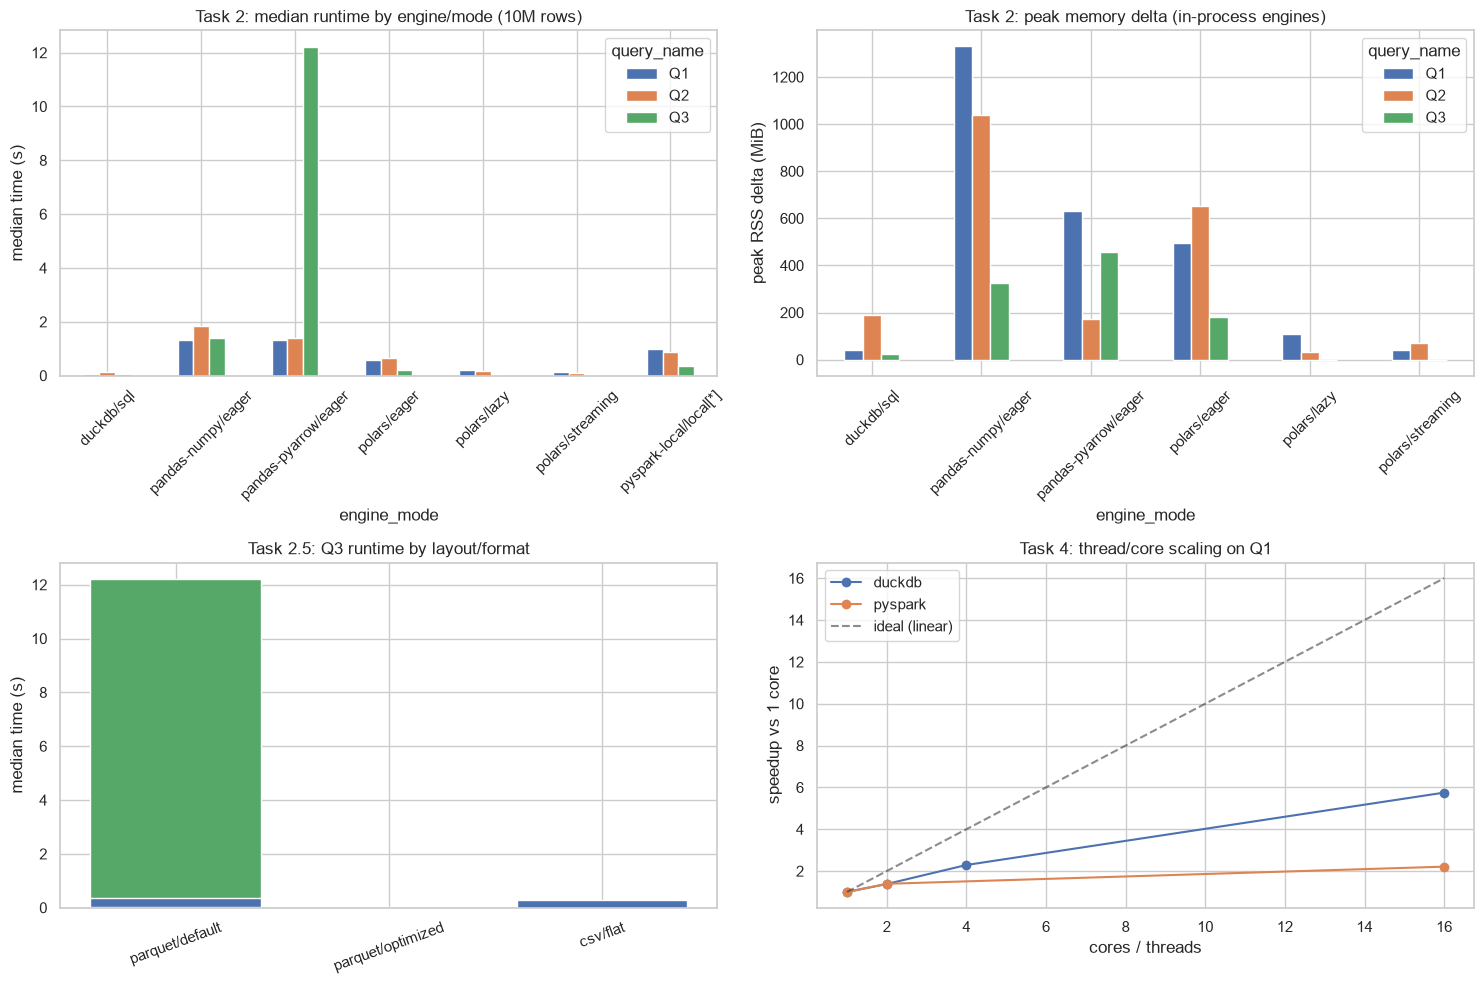

In [22]:
# Plots supporting the report: runtime by engine/query, peak memory, layout effect, scalability.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
full_df = results_df()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Task 2: median runtime by engine/mode for Q1/Q2/Q3 (default layout only).
t2 = full_df[(full_df["layout"] == "default") & (full_df["query_name"].isin(["Q1", "Q2", "Q3"]))].copy()
t2["engine_mode"] = t2["library_engine"] + "/" + t2["mode"].astype(str)
piv = t2.pivot_table(index="engine_mode", columns="query_name", values="median_time_s", aggfunc="first")
piv.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Task 2: median runtime by engine/mode (10M rows)")
axes[0, 0].set_ylabel("median time (s)")
axes[0, 0].tick_params(axis="x", rotation=45)

# (2) Peak memory by engine/mode (in-process engines only; Spark/JVM is n/a).
mem = t2.dropna(subset=["peak_memory_mb"])
mem_piv = mem.pivot_table(index="engine_mode", columns="query_name", values="peak_memory_mb", aggfunc="first")
mem_piv.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Task 2: peak memory delta (in-process engines)")
axes[0, 1].set_ylabel("peak RSS delta (MiB)")
axes[0, 1].tick_params(axis="x", rotation=45)

# (3) Task 2.5: Q3 runtime by physical layout / format.
lay = full_df[full_df["layout"].isin(["default", "optimized", "flat"])].copy()
lay = lay[lay["query_name"] == "Q3"]
lay["label"] = lay["data_format"] + "/" + lay["layout"]
axes[1, 0].bar(lay["label"], lay["median_time_s"], color=["#4c72b0", "#55a868", "#c44e52"])
axes[1, 0].set_title("Task 2.5: Q3 runtime by layout/format")
axes[1, 0].set_ylabel("median time (s)")
axes[1, 0].tick_params(axis="x", rotation=20)

# (4) Task 4: scalability speedup vs cores, with ideal-linear reference.
for engine, grp in scal_df.groupby("engine"):
    axes[1, 1].plot(grp["cores"], grp["speedup_vs_1core"], marker="o", label=engine)
_max_c = scal_df["cores"].max()
axes[1, 1].plot([1, _max_c], [1, _max_c], "k--", alpha=0.5, label="ideal (linear)")
axes[1, 1].set_title("Task 4: thread/core scaling on Q1")
axes[1, 1].set_xlabel("cores / threads")
axes[1, 1].set_ylabel("speedup vs 1 core")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### Task 5: Spark on Dataproc

Use the infrastructure from Phase 1 to run selected PySpark queries on a Dataproc cluster.

Required comparison:

- local PySpark vs. Dataproc PySpark,
- your main dataset size, and optionally one larger stress-test size if Spark overhead or scaling is not visible,
- at least one explanation based on Spark execution characteristics such as partitions, shuffle, caching, or scheduling overhead.

You may use the same generated Parquet data, uploaded to GCS. Consider using the partitioned layout if your query filters by date or another partition column.

In [23]:
# Task 5 — Spark on Dataproc (Phase 1 infrastructure). No credentials/secrets are stored here.
#
# Workflow (run in a terminal where `gcloud` is authenticated; commands are printed below):
#   1. Upload the generated Parquet to GCS.
#   2. Upload the standalone Spark job (written to disk by this cell) to the code bucket.
#   3. Submit it to the existing Dataproc cluster; the job times Q1/Q2/Q3 and prints a JSON line.
#   4. Paste that JSON into data/phase2_26L/group_02/dataproc_results.json (this cell reads it).
#
# This cell is safe to run even without gcloud: it writes the job file + runbook and, if a results
# JSON exists, renders the local-vs-Dataproc comparison.
import shutil
import subprocess

GCP_PROJECT = "tbd-2026l-321362"
DATAPROC_REGION = "europe-west1"
DATAPROC_CLUSTER = "tbd-cluster"
DATA_BUCKET = f"{GCP_PROJECT}-data"
CODE_BUCKET = f"{GCP_PROJECT}-code"
GCS_PREFIX = f"gs://{DATA_BUCKET}/phase2_26L/group_{GROUP_ID:02d}"
JOB_FILE = Path("dataproc_spark_job.py").resolve()
DATAPROC_RESULTS_JSON = OUTPUT_DIR / "dataproc_results.json"

# --- Standalone PySpark job: same Q1/Q2/Q3 as the local benchmark, reading Parquet from GCS. ---
SPARK_JOB_SOURCE = '''
import json, sys, time, statistics
from pyspark.sql import SparkSession, functions as F

events_uri, dim_uri = sys.argv[1], sys.argv[2]
Q3_START, Q3_END, Q3_CAT, TOPK, REPEATS = "2026-02-01", "2026-02-14", "electronics", 20, 3

spark = SparkSession.builder.appName("TBDPhase2Dataproc").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
events, dim = spark.read.parquet(events_uri), spark.read.parquet(dim_uri)

def q1():
    return (events.join(dim.select("product_id", "supplier_country"), "product_id")
            .groupBy("supplier_country")
            .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"),
                 F.avg("quantity").alias("avg_qty")).collect())

def q2():
    return (events.filter(F.col("order_status") == "completed").groupBy("customer_id")
            .agg(F.sum("order_value").alias("revenue"), F.count(F.lit(1)).alias("orders"))
            .orderBy(F.col("revenue").desc()).limit(TOPK).collect())

def q3():
    return (events.filter(F.col("order_date").between(F.to_date(F.lit(Q3_START)), F.to_date(F.lit(Q3_END)))
                          & (F.col("product_category") == Q3_CAT))
            .groupBy("order_date").agg(F.sum("order_value").alias("revenue"),
                                       F.count(F.lit(1)).alias("orders")).collect())

out = {"cluster_executors": spark.sparkContext.defaultParallelism, "rows": events.count()}
for name, fn in [("Q1", q1), ("Q2", q2), ("Q3", q3)]:
    times = []
    for _ in range(REPEATS):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    out[name] = round(statistics.median(times), 4)
print("DATAPROC_RESULT_JSON=" + json.dumps(out))
spark.stop()
'''
JOB_FILE.write_text(SPARK_JOB_SOURCE, encoding="utf-8")
print(f"Wrote Spark job: {JOB_FILE}")

RUNBOOK = f"""
# --- Dataproc runbook (run in an authenticated gcloud shell) ---
gcloud config set project {GCP_PROJECT}

# 1) Upload data (events + dimension; optionally the partitioned dir for partition pruning):
gsutil -m cp "{to_posix(EVENTS_PATH)}"    {GCS_PREFIX}/events.parquet
gsutil -m cp "{to_posix(DIMENSION_PATH)}" {GCS_PREFIX}/dimension.parquet

# 2) Upload the job:
gsutil cp "{JOB_FILE.as_posix()}" gs://{CODE_BUCKET}/phase2_26L/dataproc_spark_job.py

# 3) Submit to the cluster (job prints a line: DATAPROC_RESULT_JSON={{...}}):
gcloud dataproc jobs submit pyspark gs://{CODE_BUCKET}/phase2_26L/dataproc_spark_job.py \\
  --cluster={DATAPROC_CLUSTER} --region={DATAPROC_REGION} \\
  -- {GCS_PREFIX}/events.parquet {GCS_PREFIX}/dimension.parquet

# 4) Save the printed JSON object into: {DATAPROC_RESULTS_JSON}
"""
print(RUNBOOK)

if shutil.which("gcloud"):
    print("gcloud detected on PATH — you can run the runbook above from a terminal.")
else:
    print("gcloud NOT on PATH: install Google Cloud SDK and authenticate, then run the runbook.")


Wrote Spark job: C:\Users\kacpe\OneDrive\Pulpit\tbd-workshop-1\notebooks\dataproc_spark_job.py

# --- Dataproc runbook (run in an authenticated gcloud shell) ---
gcloud config set project tbd-2026l-321362

# 1) Upload data (events + dimension; optionally the partitioned dir for partition pruning):
gsutil -m cp "C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/data/phase2_26L/group_02/events.parquet"    gs://tbd-2026l-321362-data/phase2_26L/group_02/events.parquet
gsutil -m cp "C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/data/phase2_26L/group_02/dimension.parquet" gs://tbd-2026l-321362-data/phase2_26L/group_02/dimension.parquet

# 2) Upload the job:
gsutil cp "C:/Users/kacpe/OneDrive/Pulpit/tbd-workshop-1/notebooks/dataproc_spark_job.py" gs://tbd-2026l-321362-code/phase2_26L/dataproc_spark_job.py

# 3) Submit to the cluster (job prints a line: DATAPROC_RESULT_JSON={...}):
gcloud dataproc jobs submit pyspark gs://tbd-2026l-321362-code/phase2_26L/dataproc_spark_job.py \
  --cluster=tbd-clu

In [24]:
# Local PySpark vs Dataproc PySpark comparison.
# Reads the JSON produced by the Dataproc job (step 4 of the runbook). Renders "pending" until it
# exists, so the notebook stays runnable before the cluster job has been executed.
from IPython.display import Markdown, display

local_spark = {
    q: metric(q, "pyspark-local", col="median_time_s") for q in ["Q1", "Q2", "Q3"]
}

if DATAPROC_RESULTS_JSON.exists():
    dp = json.loads(DATAPROC_RESULTS_JSON.read_text(encoding="utf-8"))
    rows = []
    for q in ["Q1", "Q2", "Q3"]:
        loc, rem = local_spark.get(q), dp.get(q)
        speedup = round(loc / rem, 2) if (loc and rem) else None
        rows.append({"query": q, "local_spark_s": loc, "dataproc_s": rem,
                     "dataproc_speedup_x": speedup})
    dataproc_df = pd.DataFrame(rows)
    print(f"Dataproc cluster: {dp.get('cluster_executors')} default parallelism, "
          f"{dp.get('rows'):,} rows read.")
    display(dataproc_df)
    display(Markdown(
        "**Interpretacja.** Przy 10 mln wierszy narzut klastra przypadający na zadanie "
        "(szeregowanie sterownika/executorów, tasowanie po sieci, odczyt Parquet z GCS przez sieć "
        "zamiast z lokalnego dysku) konkuruje z jego dodatkową równoległością. To, czy Dataproc "
        "pokona lokalnego Sparka, zależy od tego, czy dołożone executory przeważą ten narzut; dla "
        "danych małych/średnich zwykle dominuje koszt sieci i szeregowania — i to jest właśnie "
        "kompromis „pojedynczy węzeł kontra klaster”, któremu poświęcone jest to laboratorium."
    ))
else:
    display(Markdown(
        f"_Wyniki Dataproc oczekują._ Uruchom powyższy runbook, następnie zapisz wydrukowany JSON do "
        f"`{DATAPROC_RESULTS_JSON}` i wykonaj tę komórkę ponownie. Bazowe czasy lokalnego Sparka "
        f"(mediany Q1/Q2/Q3): {local_spark}."
    ))


Dataproc cluster: 2 default parallelism, 10,000,000 rows read.


,query,local_spark_s,dataproc_s,dataproc_speedup_x
0,Q1,0.9842,9.3615,0.11
1,Q2,0.8763,7.6603,0.11
2,Q3,0.3721,3.4373,0.11


**Interpretacja.** Przy 10 mln wierszy narzut klastra przypadający na zadanie (szeregowanie sterownika/executorów, tasowanie po sieci, odczyt Parquet z GCS przez sieć zamiast z lokalnego dysku) konkuruje z jego dodatkową równoległością. To, czy Dataproc pokona lokalnego Sparka, zależy od tego, czy dołożone executory przeważą ten narzut; dla danych małych/średnich zwykle dominuje koszt sieci i szeregowania — i to jest właśnie kompromis „pojedynczy węzeł kontra klaster”, któremu poświęcone jest to laboratorium.

## Final notebook report

The rendered notebook is your final submission. You do not submit a separate report.

Before submitting, make sure this notebook contains:

- group id and selected data profile,
- link to this notebook in your fork,
- main dataset size (`N_ROWS`), schema summary, and physical layout,
- three query descriptions with hypotheses,
- local benchmark table for Pandas 3.0 default backend, Pandas 3.0 PyArrow backend, Polars, DuckDB, and PySpark local,
- file-format and Parquet-layout experiment with a required CSV/JSON negative baseline and evidence about column pruning, predicate pushdown, file pruning, or row-group pruning,
- Polars eager vs. lazy vs. streaming vs. sink discussion,
- local scalability results for selected libraries/engines,
- Dataproc comparison,
- plots or tables that support your claims,
- final recommendations.

Do not commit generated data files, benchmark outputs, credentials, or local environment files.


### Final answers

The answers below are computed from the measured results and are visible in the rendered notebook.

In [25]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 1: Which query best exposes the difference between DataFrame and SQL engines?
FINAL_ANSWER_1 = f"""
**Q1 (złączenie + agregacja po kategorii).** To właśnie przy złączeniu optymalizatory silników SQL
pokazują swoją wartość: w DuckDB wystarczy zadeklarować
`FROM events JOIN products USING(product_id) GROUP BY supplier_country`, a planista sam wybiera stronę
budującą i sondującą, przepycha projekcję (tylko `product_id` oraz kolumny agregowane) do odczytu
Parquet i nigdy nie materializuje pełnego złączenia. Interfejsy DataFrame są bardziej imperatywne —
Pandas musi wykonać `read_parquet` (wszystkie kolumny), `merge`, a następnie `groupby`, materializując
połączoną ramkę o ~10 mln wierszy; Polars nadrabia tę różnicę dopiero w trybie leniwym, w którym także
zachowuje się jak optymalizator. Zmierzone mediany Q1: DuckDB ≈ {metric('Q1','duckdb','sql')}s wobec
Pandas (numpy) ≈ {metric('Q1','pandas-numpy','eager')}s. Q2 i Q3 to filtry/agregacje, które każdy silnik
wyraża podobnie, więc słabiej uwypuklają różnicę między interfejsami.
"""
display_answer("Odpowiedź końcowa 1", FINAL_ANSWER_1)

**Odpowiedź końcowa 1**

**Q1 (złączenie + agregacja po kategorii).** To właśnie przy złączeniu optymalizatory silników SQL
pokazują swoją wartość: w DuckDB wystarczy zadeklarować
`FROM events JOIN products USING(product_id) GROUP BY supplier_country`, a planista sam wybiera stronę
budującą i sondującą, przepycha projekcję (tylko `product_id` oraz kolumny agregowane) do odczytu
Parquet i nigdy nie materializuje pełnego złączenia. Interfejsy DataFrame są bardziej imperatywne —
Pandas musi wykonać `read_parquet` (wszystkie kolumny), `merge`, a następnie `groupby`, materializując
połączoną ramkę o ~10 mln wierszy; Polars nadrabia tę różnicę dopiero w trybie leniwym, w którym także
zachowuje się jak optymalizator. Zmierzone mediany Q1: DuckDB ≈ 0.0737s wobec
Pandas (numpy) ≈ 1.3361s. Q2 i Q3 to filtry/agregacje, które każdy silnik
wyraża podobnie, więc słabiej uwypuklają różnicę między interfejsami.

In [26]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 2: Which query is most memory-sensitive?
FINAL_ANSWER_2 = f"""
**Q1 (złączenie) dla silników zachłannych oraz — ogólnie — zapytanie o dużym wyniku z Zadania 3.1.**
O zużyciu pamięci decyduje to, ile kolumn/wierszy trafia naraz do pamięci RAM. Q1 zmusza Pandas do
przechowywania pełnych danych wejściowych wraz z połączoną ramką; Q2 trzyma pełne wejście plus tabelę
grup o ~200 tys. wierszy; Q3 jest selektywne i pozostaje niewielkie. Zmierzone przyrosty szczytu
pamięci (peak RSS, silniki działające w procesie): Pandas-numpy Q1 ≈ {metric('Q1','pandas-numpy','eager','peak_memory_mb')} MiB,
Q2 ≈ {metric('Q2','pandas-numpy','eager','peak_memory_mb')} MiB, Q3 ≈ {metric('Q3','pandas-numpy','eager','peak_memory_mb')} MiB.
Najbardziej wrażliwy na pamięć jest przypadek zapytania o dużym wyniku z Zadania 3.1, mierzony w
izolowanych podprocesach (peak_wset): zachłanny Polars osiągnął szczyt ≈ {metric('T3.1','polars','eager','peak_memory_mb')} MiB,
ponieważ `read_parquet` wczytuje wszystkie 12 kolumn 10 mln wierszy przed filtrowaniem, podczas gdy
tryby z przepychaniem (pushdown) czytają tylko 6 rzutowanych kolumn i wszystkie utrzymują się w okolicy
≈ {metric('T3.1','polars','streaming-collect','peak_memory_mb')}–{metric('T3.1','polars','streaming-sink','peak_memory_mb')} MiB
(leniwy collect, strumieniowy collect oraz sink podobnie). Główną dźwignią pamięci jest tu zatem
**przepychanie projekcji/predykatów (pushdown)** — unikanie zachłannego wczytania wszystkich kolumn —
a nie to, czy wynik jest ostatecznie materializowany w RAM, czy zapisywany strumieniowo na dysk.
"""
display_answer("Odpowiedź końcowa 2", FINAL_ANSWER_2)

**Odpowiedź końcowa 2**

**Q1 (złączenie) dla silników zachłannych oraz — ogólnie — zapytanie o dużym wyniku z Zadania 3.1.**
O zużyciu pamięci decyduje to, ile kolumn/wierszy trafia naraz do pamięci RAM. Q1 zmusza Pandas do
przechowywania pełnych danych wejściowych wraz z połączoną ramką; Q2 trzyma pełne wejście plus tabelę
grup o ~200 tys. wierszy; Q3 jest selektywne i pozostaje niewielkie. Zmierzone przyrosty szczytu
pamięci (peak RSS, silniki działające w procesie): Pandas-numpy Q1 ≈ 1330.9 MiB,
Q2 ≈ 1040.5 MiB, Q3 ≈ 323.6 MiB.
Najbardziej wrażliwy na pamięć jest przypadek zapytania o dużym wyniku z Zadania 3.1, mierzony w
izolowanych podprocesach (peak_wset): zachłanny Polars osiągnął szczyt ≈ 1865.3 MiB,
ponieważ `read_parquet` wczytuje wszystkie 12 kolumn 10 mln wierszy przed filtrowaniem, podczas gdy
tryby z przepychaniem (pushdown) czytają tylko 6 rzutowanych kolumn i wszystkie utrzymują się w okolicy
≈ 475.3–501.7 MiB
(leniwy collect, strumieniowy collect oraz sink podobnie). Główną dźwignią pamięci jest tu zatem
**przepychanie projekcji/predykatów (pushdown)** — unikanie zachłannego wczytania wszystkich kolumn —
a nie to, czy wynik jest ostatecznie materializowany w RAM, czy zapisywany strumieniowo na dysk.

In [27]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 3: Did lazy execution change the amount of data read or materialized?
FINAL_ANSWER_3 = f"""
**Tak.** Silniki leniwe/SQL przepychają projekcję i predykat do czytnika Parquet, dzięki czemu czytają
mniej kolumn, a przy selektywnych filtrach — mniej grup wierszy niż zachłanna ścieżka „wczytaj
wszystko”. `EXPLAIN ANALYZE` dla Q3 z Zadania 2.5 pokazuje to wprost: przy zoptymalizowanym układzie
(posortowanym, z grupami wierszy po 100 tys.) odczyt Parquet po pominięciu grup wierszy (pruning)
zwraca tylko pasujące wiersze, podczas gdy układ o losowej kolejności nie może niczego pominąć i
skanuje znacznie więcej. Polars (leniwy/strumieniowy) oraz DuckDB materializują jedynie niewielki,
zagregowany wynik; zachłanny Pandas najpierw materializuje całą tabelę (wszystkie kolumny), niezależnie
od zapytania. Leniwe wykonanie zmniejszyło więc zarówno ilość odczytanych danych (projekcja + predykat
+ pomijanie grup wierszy), jak i ilość zmaterializowanych danych (tylko wynik, nie wejście).
"""
display_answer("Odpowiedź końcowa 3", FINAL_ANSWER_3)

**Odpowiedź końcowa 3**

**Tak.** Silniki leniwe/SQL przepychają projekcję i predykat do czytnika Parquet, dzięki czemu czytają
mniej kolumn, a przy selektywnych filtrach — mniej grup wierszy niż zachłanna ścieżka „wczytaj
wszystko”. `EXPLAIN ANALYZE` dla Q3 z Zadania 2.5 pokazuje to wprost: przy zoptymalizowanym układzie
(posortowanym, z grupami wierszy po 100 tys.) odczyt Parquet po pominięciu grup wierszy (pruning)
zwraca tylko pasujące wiersze, podczas gdy układ o losowej kolejności nie może niczego pominąć i
skanuje znacznie więcej. Polars (leniwy/strumieniowy) oraz DuckDB materializują jedynie niewielki,
zagregowany wynik; zachłanny Pandas najpierw materializuje całą tabelę (wszystkie kolumny), niezależnie
od zapytania. Leniwe wykonanie zmniejszyło więc zarówno ilość odczytanych danych (projekcja + predykat
+ pomijanie grup wierszy), jak i ilość zmaterializowanych danych (tylko wynik, nie wejście).

In [28]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 4: Did streaming collection reduce memory, runtime, or both?
FINAL_ANSWER_4 = f"""
**Ani jednego, ani drugiego w sposób wyraźny — względem leniwego `collect()` przetwarzanie strumieniowe
niemal nie zmieniło tu ani pamięci, ani czasu; prawdziwa oszczędność pojawiła się krok wcześniej, przy
leniwym przepychaniu (pushdown) względem trybu zachłannego.** Pomiar w izolowanych podprocesach: leniwy
collect ≈ {metric('T3.1','polars','lazy-collect','peak_memory_mb')} MiB
({metric('T3.1','polars','lazy-collect')}s) oraz strumieniowy collect ≈ {metric('T3.1','polars','streaming-collect','peak_memory_mb')} MiB
({metric('T3.1','polars','streaming-collect')}s) są praktycznie identyczne, ponieważ
`collect(engine="streaming")` i tak zwraca cały wynik jako ramkę DataFrame trzymaną w pamięci. Co
istotne, `sink_parquet` (≈ {metric('T3.1','polars','streaming-sink','peak_memory_mb')} MiB) **nie** zszedł
poniżej trybów collect dla tego zapytania: choć nigdy nie materializuje wyniku w Pythonie, o szczycie
pamięci decyduje zbiór roboczy skanowania i filtrowania w kolejnych porcjach, a zachowany wynik tego
zapytania jest niewielki w stosunku do wejścia. Jedyna duża różnica to tryb zachłanny ≈ {metric('T3.1','polars','eager','peak_memory_mb')} MiB
(wczytanie wszystkich kolumn) wobec dowolnego trybu z przepychaniem. Wniosek: strumieniowanie/sink
zmniejszają pamięć tylko wtedy, gdy **wynik** jest duży w stosunku do skanowania; gdy dominuje
skanowanie (jak tutaj), głównie ograniczają wzrost w najgorszym przypadku, zamiast pobić collect
trzymający wynik w pamięci.
"""
display_answer("Odpowiedź końcowa 4", FINAL_ANSWER_4)

**Odpowiedź końcowa 4**

**Ani jednego, ani drugiego w sposób wyraźny — względem leniwego `collect()` przetwarzanie strumieniowe
niemal nie zmieniło tu ani pamięci, ani czasu; prawdziwa oszczędność pojawiła się krok wcześniej, przy
leniwym przepychaniu (pushdown) względem trybu zachłannego.** Pomiar w izolowanych podprocesach: leniwy
collect ≈ 478.7 MiB
(0.1108s) oraz strumieniowy collect ≈ 475.3 MiB
(0.107s) są praktycznie identyczne, ponieważ
`collect(engine="streaming")` i tak zwraca cały wynik jako ramkę DataFrame trzymaną w pamięci. Co
istotne, `sink_parquet` (≈ 501.7 MiB) **nie** zszedł
poniżej trybów collect dla tego zapytania: choć nigdy nie materializuje wyniku w Pythonie, o szczycie
pamięci decyduje zbiór roboczy skanowania i filtrowania w kolejnych porcjach, a zachowany wynik tego
zapytania jest niewielki w stosunku do wejścia. Jedyna duża różnica to tryb zachłanny ≈ 1865.3 MiB
(wczytanie wszystkich kolumn) wobec dowolnego trybu z przepychaniem. Wniosek: strumieniowanie/sink
zmniejszają pamięć tylko wtedy, gdy **wynik** jest duży w stosunku do skanowania; gdy dominuje
skanowanie (jak tutaj), głównie ograniczają wzrost w najgorszym przypadku, zamiast pobić collect
trzymający wynik w pamięci.

In [29]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 5: When was a streaming sink more appropriate than collecting the result?
FINAL_ANSWER_5 = f"""
**Wtedy, gdy wynik trzeba utrwalić i jest duży w stosunku do skanowania, więc nie powinien w całości
przebywać w pamięci Pythona.** `sink_parquet` strumieniowo zapisuje kolejne porcje wprost na dysk i
nigdy nie buduje całej ramki wynikowej — czyli dokładnie to, czego potrzebuje etap ETL zasilający
kolejne zadanie. Zastrzeżenie z naszych własnych pomiarów: dla zapytania z Zadania 3.1 zmierzony szczyt
sink (≈ {metric('T3.1','polars','streaming-sink','peak_memory_mb')} MiB) był mniej więcej taki sam jak dla
leniwego/strumieniowego `collect()`
(≈ {metric('T3.1','polars','lazy-collect','peak_memory_mb')}–{metric('T3.1','polars','streaming-collect','peak_memory_mb')} MiB),
ponieważ ten wynik ma umiarkowany rozmiar, więc o szczycie pamięci decyduje zbiór roboczy skanowania.
Przewaga sink rośnie, w miarę jak wynik zbliża się do rozmiaru wejścia — wtedy zebranie go w pamięci RAM
by ją przepełniło. Zatem: duży wynik zapisywany „na przelot”, którego nie potrzebujesz w procesie →
`sink`; mały wynik używany w programie → `collect`.
"""
display_answer("Odpowiedź końcowa 5", FINAL_ANSWER_5)

**Odpowiedź końcowa 5**

**Wtedy, gdy wynik trzeba utrwalić i jest duży w stosunku do skanowania, więc nie powinien w całości
przebywać w pamięci Pythona.** `sink_parquet` strumieniowo zapisuje kolejne porcje wprost na dysk i
nigdy nie buduje całej ramki wynikowej — czyli dokładnie to, czego potrzebuje etap ETL zasilający
kolejne zadanie. Zastrzeżenie z naszych własnych pomiarów: dla zapytania z Zadania 3.1 zmierzony szczyt
sink (≈ 501.7 MiB) był mniej więcej taki sam jak dla
leniwego/strumieniowego `collect()`
(≈ 478.7–475.3 MiB),
ponieważ ten wynik ma umiarkowany rozmiar, więc o szczycie pamięci decyduje zbiór roboczy skanowania.
Przewaga sink rośnie, w miarę jak wynik zbliża się do rozmiaru wejścia — wtedy zebranie go w pamięci RAM
by ją przepełniło. Zatem: duży wynik zapisywany „na przelot”, którego nie potrzebujesz w procesie →
`sink`; mały wynik używany w programie → `collect`.

In [30]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 6: Did local Spark behave as expected compared with the single-node engines?
FINAL_ANSWER_6 = f"""
**Tak — przy tym rozmiarze lokalny Spark był najwolniejszy, zgodnie z oczekiwaniami.** Przy 10 mln
wierszy mediany Q1 wyniosły: DuckDB ≈ {metric('Q1','duckdb','sql')}s oraz Polars (leniwy) ≈ {metric('Q1','polars','lazy')}s,
podczas gdy lokalny Spark ≈ {metric('Q1','pyspark-local')}s. Spark ponosi koszty stałe, których silniki
działające w procesie nie mają: uruchomienie JVM/sterownika, planowanie zapytania w Catalyst,
serializacja zadań oraz rzeczywiste (choć lokalne) tasowanie (shuffle) na potrzeby grupowania/złączenia.
Koszty te są w przybliżeniu stałe na zapytanie, więc przy danych małych/średnich dominują i Spark
przegrywa; zwracają się dopiero wtedy, gdy danych jest na tyle dużo, że liczą się rozproszona
równoległość i zrzut na dysk. To zachowanie oczekiwane, które uzasadnia Zadanie 5 (oraz granicę
decyzyjną z 3.3): Spark jest stworzony do skali i odporności, a nie do minimalizowania czasu odpowiedzi
na 10 mln wierszy, które wygodnie mieszczą się na jednym węźle.
"""
display_answer("Odpowiedź końcowa 6", FINAL_ANSWER_6)

**Odpowiedź końcowa 6**

**Tak — przy tym rozmiarze lokalny Spark był najwolniejszy, zgodnie z oczekiwaniami.** Przy 10 mln
wierszy mediany Q1 wyniosły: DuckDB ≈ 0.0737s oraz Polars (leniwy) ≈ 0.2004s,
podczas gdy lokalny Spark ≈ 0.9842s. Spark ponosi koszty stałe, których silniki
działające w procesie nie mają: uruchomienie JVM/sterownika, planowanie zapytania w Catalyst,
serializacja zadań oraz rzeczywiste (choć lokalne) tasowanie (shuffle) na potrzeby grupowania/złączenia.
Koszty te są w przybliżeniu stałe na zapytanie, więc przy danych małych/średnich dominują i Spark
przegrywa; zwracają się dopiero wtedy, gdy danych jest na tyle dużo, że liczą się rozproszona
równoległość i zrzut na dysk. To zachowanie oczekiwane, które uzasadnia Zadanie 5 (oraz granicę
decyzyjną z 3.3): Spark jest stworzony do skali i odporności, a nie do minimalizowania czasu odpowiedzi
na 10 mln wierszy, które wygodnie mieszczą się na jednym węźle.

In [31]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 7: At what dataset size or query shape would you move from local processing to a cluster?
FINAL_ANSWER_7 = f"""
**Przejdź na klaster, gdy zbiór roboczy przestaje wygodnie mieścić się w pamięci RAM jednego węzła albo
gdy zadanie wymaga operacji na poziomie klastra — a nie tylko dlatego, że liczba wierszy jest „duża”.**
Na tej maszynie z {round(psutil.virtual_memory().total / 2**30, 1)} GiB RAM 10 mln wierszy to drobiazg,
a lokalny Spark już przegrywa z DuckDB/Polars w każdym zapytaniu. Ekstrapolując szczyt pamięci
zachłannej ścieżki z Zadania 3.1, przetwarzanie w pamięci dla tego schematu zbliżyłoby się do granicy
lokalnej pamięci RAM gdzieś w okolicach niskich setek milionów wierszy; to — albo zapytanie, którego
wynik pośredni/końcowy sam jest tak duży, albo silnie skośne, szerokie tasowanie (shuffle), albo
potrzeba odporności na awarie / szeregowania / wielu równoczesnych użytkowników — stanowi sygnał do
przejścia. Konkretnie u nas: pozostajemy na pojedynczym węźle mniej więcej do kilkudziesięciu GB zbioru
roboczego; powyżej tego albo gdy wymagana jest odporność i współdzielone szeregowanie, przechodzimy na
Spark/Dataproc.
"""
display_answer("Odpowiedź końcowa 7", FINAL_ANSWER_7)

**Odpowiedź końcowa 7**

**Przejdź na klaster, gdy zbiór roboczy przestaje wygodnie mieścić się w pamięci RAM jednego węzła albo
gdy zadanie wymaga operacji na poziomie klastra — a nie tylko dlatego, że liczba wierszy jest „duża”.**
Na tej maszynie z 31.9 GiB RAM 10 mln wierszy to drobiazg,
a lokalny Spark już przegrywa z DuckDB/Polars w każdym zapytaniu. Ekstrapolując szczyt pamięci
zachłannej ścieżki z Zadania 3.1, przetwarzanie w pamięci dla tego schematu zbliżyłoby się do granicy
lokalnej pamięci RAM gdzieś w okolicach niskich setek milionów wierszy; to — albo zapytanie, którego
wynik pośredni/końcowy sam jest tak duży, albo silnie skośne, szerokie tasowanie (shuffle), albo
potrzeba odporności na awarie / szeregowania / wielu równoczesnych użytkowników — stanowi sygnał do
przejścia. Konkretnie u nas: pozostajemy na pojedynczym węźle mniej więcej do kilkudziesięciu GB zbioru
roboczego; powyżej tego albo gdy wymagana jest odporność i współdzielone szeregowanie, przechodzimy na
Spark/Dataproc.

In [32]:
from IPython.display import Markdown, display

def display_answer(title, text):
    display(Markdown(f"**{title}**\n\n{text.strip()}"))

# FINAL 8: How did Pandas default backend compare with the PyArrow dtype backend?
def _avg_time(engine):
    vals = [metric(q, engine, "eager") for q in ["Q1", "Q2", "Q3"]]
    vals = [v for v in vals if v is not None]
    return round(sum(vals) / len(vals), 3) if vals else None

def _avg_mem(engine):
    vals = [metric(q, engine, "eager", "peak_memory_mb") for q in ["Q1", "Q2", "Q3"]]
    vals = [v for v in vals if v is not None]
    return round(sum(vals) / len(vals), 1) if vals else None

FINAL_ANSWER_8 = f"""
**Backend typów PyArrow zmienił typy danych i zużycie pamięci bardziej niż samą szybkość.** Przy
backendzie NumPy Pandas 3.0 wczytuje nasze kolumny tekstowe jako nowy, dedykowany typ string, a liczby
całkowite/zmiennoprzecinkowe jako tablice NumPy; przy `dtype_backend="pyarrow"` każda kolumna staje się
nullowalnym typem opartym na Arrow (np. `int64[pyarrow]`, `double[pyarrow]`, `string[pyarrow]`,
`date32[pyarrow]`). Uśredniając po Q1/Q2/Q3: średnia mediana czasu numpy ≈ {_avg_time('pandas-numpy')}s
wobec pyarrow ≈ {_avg_time('pandas-pyarrow')}s; średni przyrost szczytu pamięci (peak RSS) numpy ≈ {_avg_mem('pandas-numpy')} MiB
wobec pyarrow ≈ {_avg_mem('pandas-pyarrow')} MiB. Backend Arrow pomaga najbardziej po stronie tekstu i
wejścia-wyjścia (zwarte przechowywanie łańcuchów w Arrow, odczyt bez kopiowania z czytnika Parquet),
natomiast grupowania obciążające procesor bywają porównywalne lub czasem wolniejsze, ponieważ część
operacji Pandas wciąż przechodzi z powrotem przez NumPy. Tak czy inaczej oba backendy są dalekie od
DuckDB/Polars, ponieważ Pandas nie ma optymalizatora zapytań i najpierw wczytuje całą tabelę.
"""
display_answer("Odpowiedź końcowa 8", FINAL_ANSWER_8)


**Odpowiedź końcowa 8**

**Backend typów PyArrow zmienił typy danych i zużycie pamięci bardziej niż samą szybkość.** Przy
backendzie NumPy Pandas 3.0 wczytuje nasze kolumny tekstowe jako nowy, dedykowany typ string, a liczby
całkowite/zmiennoprzecinkowe jako tablice NumPy; przy `dtype_backend="pyarrow"` każda kolumna staje się
nullowalnym typem opartym na Arrow (np. `int64[pyarrow]`, `double[pyarrow]`, `string[pyarrow]`,
`date32[pyarrow]`). Uśredniając po Q1/Q2/Q3: średnia mediana czasu numpy ≈ 1.523s
wobec pyarrow ≈ 4.98s; średni przyrost szczytu pamięci (peak RSS) numpy ≈ 898.3 MiB
wobec pyarrow ≈ 421.0 MiB. Backend Arrow pomaga najbardziej po stronie tekstu i
wejścia-wyjścia (zwarte przechowywanie łańcuchów w Arrow, odczyt bez kopiowania z czytnika Parquet),
natomiast grupowania obciążające procesor bywają porównywalne lub czasem wolniejsze, ponieważ część
operacji Pandas wciąż przechodzi z powrotem przez NumPy. Tak czy inaczej oba backendy są dalekie od
DuckDB/Polars, ponieważ Pandas nie ma optymalizatora zapytań i najpierw wczytuje całą tabelę.